# Comparing penalties taken during male vs female international tournaments

## Import libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from statsbombpy import sb 

## Show all rows and columns

In [2]:
# Show all columns
pd.set_option('display.max_columns', None)

## Extract penalties from tournaments

### Import all competitions to find tournament ids

In [3]:
all_competitions = sb.competitions()

c:\Users\aquan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [4]:
all_competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


### Extract id for tournaments

In [5]:
tournament_infos = [
    {'competition_id': 43, 'season_id': 3, 'label': 'men_wc_2018', 'gender': 'male'}, # World Cup 2018
    {'competition_id': 43, 'season_id': 106, 'label': 'men_wc_2022', 'gender': 'male'}, # World Cup 2022
    {'competition_id': 55, 'season_id': 43, 'label': 'men_euro_2020', 'gender': 'male'},  # European Championship 2020
    {'competition_id': 55, 'season_id': 282, 'label': 'men_euro_2024', 'gender': 'male'}, # European Championship 2024
    {'competition_id': 72, 'season_id': 30, 'label': 'women_wc_2019', 'gender': 'female'},  # Women's World Cup 2019
    {'competition_id': 72, 'season_id': 107, 'label': 'women_wc_2023', 'gender': 'female'},  # Women's World Cup 2023
    {'competition_id': 53, 'season_id': 106, 'label': 'women_euro_2022', 'gender': 'female'}, # Women's European Championship 2022
    {'competition_id': 53, 'season_id': 315, 'label': 'women_euro_2025', 'gender': 'female'} # Women's European Championship 2025
]

### Extract penalties from tournaments

In [6]:
penalties_by_tournament = {}

In [7]:
# for tournament_info in tournament_infos:
#     matches = sb.matches(tournament_info['competition_id'], tournament_info['season_id'])
#     tournament_penalties = []

#     for match_id in matches['match_id']:
#         shots = sb.events(match_id=match_id, split=True, flatten_attrs=True)['shots']
#         if shots.empty:
#             continue
#         penalties = shots[shots['shot_type'] == 'Penalty']
#         penalties['gender'] = tournament_info['gender']
#         penalties["match_id"] = match_id
#         tournament_penalties.append(penalties)

#     penalties_by_tournament[tournament_info['label']] = pd.concat(tournament_penalties, ignore_index=True) if tournament_penalties else pd.DataFrame()
#     print(f"{tournament_info['label']}: {len(penalties_by_tournament[tournament_info['label']])} penalties")

## Extract penalties data into files for easier future reference

In [8]:
# Save
for label, df in penalties_by_tournament.items():
    df.to_pickle(f"penalty_data/{label}.pkl")

In [9]:
penalties_by_tournament = {
    t['label']: pd.read_pickle(f"penalty_data/{t['label']}.pkl")
    for t in tournament_infos
}

In [10]:
penalties_by_tournament['men_euro_2020'].head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_outcome,shot_first_time,shot_technique,shot_body_part,shot_type,shot_freeze_frame,possession_team_id,team_id,player_id,shot_key_pass_id,under_pressure,shot_open_goal,shot_deflected,shot_saved_to_post,off_camera,gender,shot_aerial_won,shot_one_on_one,shot_saved_off_target,shot_follows_dribble,out,shot_redirect,end_x,end_y,end_z,outcome_class
0,5e003ca8-3bc5-4ed7-b611-f53ead86ef50,2182,2,00:11:11.428,56,11,Shot,104,North Macedonia,Other,North Macedonia,Ezgjan Alioski,Left Back,"[108.0, 40.0]",0.308851,[2ff72314-8bd3-440d-afbf-f62b20b93d23],3788758,0.7835,"[119.1, 42.3, 0.7]",Saved,NaN,Normal,Left Foot,Penalty,NaN,2358,2358,4713,NaN,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,NaN,NaN,119.1,42.3,0.7,Saved
1,7f391b06-e355-4c61-b58b-2d812d74c418,3006,2,00:38:32.444,83,32,Shot,145,Ukraine,Other,Ukraine,Ruslan Malinovskiy,Center Attacking Midfield,"[108.3, 40.1]",0.281681,[98c3dc32-b370-49fe-a3ed-9ee33742fe5b],3788758,0.7835,"[119.2, 37.6, 0.7]",Saved,NaN,Normal,Left Foot,Penalty,NaN,911,911,16557,NaN,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,NaN,NaN,119.2,37.6,0.7,Saved
2,7888d3d0-dd0d-4025-a156-03e3938ff63c,1416,1,00:30:01.429,30,1,Shot,39,Portugal,Other,Portugal,Cristiano Ronaldo dos Santos Aveiro,Center Forward,"[108.1, 40.1]",0.437985,[989cd639-d700-461b-8ec1-342c934dd6b4],3788773,0.7835,"[120.0, 38.4, 0.9]",Goal,NaN,Normal,Right Foot,Penalty,NaN,780,780,5207,NaN,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,NaN,NaN,120.0,38.4,0.9,Goal
3,b79df704-f32a-46c9-be8b-de78c90eb9c3,2023,1,00:46:44.964,46,44,Shot,63,France,Other,France,Karim Benzema,Center Forward,"[108.0, 40.0]",0.447307,[c86b3357-001e-4000-aa29-e15aba546f68],3788773,0.7835,"[120.0, 37.5, 1.6]",Goal,NaN,Normal,Right Foot,Penalty,NaN,771,771,19677,NaN,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,NaN,NaN,120.0,37.5,1.6,Goal
4,993fc577-76c0-4730-9c03-1417867b01de,2646,2,00:14:31.362,59,31,Shot,89,Portugal,Other,Portugal,Cristiano Ronaldo dos Santos Aveiro,Center Forward,"[107.9, 40.0]",0.559754,[adc6d57c-6a27-411c-814e-712e83f16bb4],3788773,0.7835,"[120.0, 36.8, 0.2]",Goal,NaN,Normal,Right Foot,Penalty,NaN,780,780,5207,NaN,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,NaN,NaN,120.0,36.8,0.2,Goal


In [11]:
print(penalties_by_tournament['men_euro_2020'][penalties_by_tournament['men_euro_2020']['player'] == 'Marcus Rashford']['position'].unique())

<StringArray>
['Right Back']
Length: 1, dtype: str


In [12]:
print(penalties_by_tournament['men_euro_2024']['position'].unique())

<StringArray>
[    'Right Center Midfield',            'Center Forward',
       'Left Center Forward',      'Right Center Forward',
  'Right Attacking Midfield',               'Center Back',
  'Right Defensive Midfield',         'Right Center Back',
            'Left Wing Back',   'Left Attacking Midfield',
           'Right Wing Back',                'Right Wing',
 'Center Attacking Midfield',                'Right Back',
             'Left Midfield',                 'Left Wing',
                 'Left Back',            'Right Midfield',
   'Left Defensive Midfield']
Length: 19, dtype: str


In [13]:
print(penalties_by_tournament['men_wc_2018']['position'].unique())

<StringArray>
[      'Left Center Forward',          'Left Center Back',
      'Right Center Forward',                'Right Wing',
         'Right Center Back',     'Right Center Midfield',
 'Center Defensive Midfield',      'Left Center Midfield',
            'Right Midfield',   'Left Attacking Midfield',
  'Right Attacking Midfield', 'Center Attacking Midfield',
           'Right Wing Back',   'Left Defensive Midfield',
         'Secondary Striker',             'Left Midfield',
                 'Left Back',            'Center Forward',
  'Right Defensive Midfield',                 'Left Wing',
                'Right Back',           'Center Midfield']
Length: 22, dtype: str


In [14]:
print(penalties_by_tournament['men_wc_2022']['position'].unique())

<StringArray>
[     'Right Center Forward',            'Center Forward',
       'Left Center Forward',                 'Left Wing',
   'Left Defensive Midfield',            'Left Wing Back',
          'Left Center Back',            'Right Midfield',
 'Center Defensive Midfield',  'Right Defensive Midfield',
                'Right Back',     'Right Center Midfield',
                'Right Wing',      'Left Center Midfield',
           'Right Wing Back',             'Left Midfield',
               'Center Back', 'Center Attacking Midfield']
Length: 18, dtype: str


In [15]:
print(penalties_by_tournament['women_euro_2022'][penalties_by_tournament['women_euro_2022']['player'] == 'Chloe Kelly']['position'].unique())

<StringArray>
[]
Length: 0, dtype: str


In [16]:
print(penalties_by_tournament['women_euro_2025'][penalties_by_tournament['women_euro_2025']['player'] == 'Chloe Kelly']['position'].unique())

<StringArray>
['Left Wing', 'Right Midfield']
Length: 2, dtype: str


In [17]:
print(penalties_by_tournament['women_wc_2019'][penalties_by_tournament['women_wc_2019']['player'] == 'Chloe Kelly']['position'].unique())

<StringArray>
[]
Length: 0, dtype: str


In [18]:
print(penalties_by_tournament['women_wc_2023'][penalties_by_tournament['women_wc_2023']['player'] == 'Chloe Kelly']['position'].unique())

<StringArray>
['Right Midfield']
Length: 1, dtype: str


## Group penalties by gender

In [19]:
def combine_gender(penalties_by_tournament, labels):
    return pd.concat(
        [penalties_by_tournament[l] for l in labels],
        ignore_index=True
    )

## Plot penalties outcomes

### Plot outcomes by tournaments

In [20]:
# ── Outcome classification ──────────────────────────────────────────────────
outcome_map = {
    'Goal': 'Goal',
    'Saved': 'Saved',
    'Saved to Post': 'Saved',
    'Post': 'Woodwork',
    'Off T': 'Wide/Over',
}

In [21]:
# ── Visual config ───────────────────────────────────────────────────────────
post_color = 'black'
bg_color = '#e5e5e5'

In [22]:
outcome_styles = {
    'Goal': {'color': 'green', 'marker': 'o'},
    'Saved': {'color': 'red', 'marker': 'X'},
    'Woodwork': {'color': 'orange', 'marker': 'D'},
    'Wide/Over': {'color': 'gray', 'marker': 'D'},
}

In [23]:
goal_height = 2.67   # metres — StatsBomb z is in metres
goal_left = 36
goal_right = 44

In [24]:
zone_6_coords = {
    'Top Left':    (36.00, 38.67, 1.22, 2.44),
    'Top Centre':  (38.67, 41.33, 1.22, 2.44),
    'Top Right':   (41.33, 44.00, 1.22, 2.44),
    'Bot Left':    (36.00, 38.67, 0.00, 1.22),
    'Bot Centre':  (38.67, 41.33, 0.00, 1.22),
    'Bot Right':   (41.33, 44.00, 0.00, 1.22),
}

In [25]:
def classify_zone_6(end_y, end_z):
    # Clamp to goal boundaries — post hits and wide shots go to nearest zone
    y = max(36.0, min(44.0, end_y))
    z = max(0.0,  min(2.44, end_z))

    height = 'Top' if z >= 1.22 else 'Bot'

    if y <= 38.67:
        col = 'Left'
    elif y <= 41.33:
        col = 'Centre'
    else:
        col = 'Right'

    return f"{height} {col}"

In [26]:
# ── Step 1: parse end locations + classify outcomes for every tournament ────
for df in penalties_by_tournament.values():
    if df.empty:
        continue
    df[['end_x', 'end_y', 'end_z']] = df['shot_end_location'].apply(pd.Series)
    df['end_z'] = df['end_z'].fillna(0)
    oc = 'shot_outcome' if 'shot_outcome' in df.columns else 'shot_outcome_name'
    df['outcome_class'] = df[oc].map(outcome_map).fillna('Miss')
    df['zone_6'] = df.apply(
        lambda r: classify_zone_6(r['end_y'], r['end_z']), axis=1
    )

In [27]:
# ── Goal frame (Hudl-style thick lines + dashed zone dividers) ──────────────
def draw_goal(ax):
    post_kw = dict(c=post_color, linewidth=10, zorder=1, solid_capstyle='butt')
    ax.plot([goal_left,  goal_left],  [0, goal_height], **post_kw)   # left post
    ax.plot([goal_right, goal_right], [0, goal_height], **post_kw)   # right post
    ax.plot([goal_left,  goal_right], [goal_height, goal_height], **post_kw)  # crossbar

    zone_kw = dict(c=post_color, linewidth=1.5, linestyle='dashed', zorder=1)
    ax.plot([38.67, 38.67], [0, goal_height], **zone_kw)  # left | centre
    ax.plot([41.33, 41.33], [0, goal_height], **zone_kw)  # centre | right

In [28]:
# ── Scatter penalties ───────────────────────────────────────────────────────
def plot_pens(df, ax):
    for outcome, style in outcome_styles.items():
        sub = df[df['outcome_class'] == outcome]
        if sub.empty:
            continue
        ax.scatter(sub['end_y'], sub['end_z'],
                   s=120, marker=style['marker'],
                   c=style['color'], ec='white', lw=1,
                   alpha=1, zorder=2)

In [29]:
# ── Single tournament panel ─────────────────────────────────────────────────
def plot_tournament_ax(ax, df, display_name):
    ax.set_facecolor(bg_color)
    draw_goal(ax)
    plot_pens(df, ax)

    # Zone percentages (L / C / R)
    total = len(df)
    if total > 0:
        l_pct = int(len(df[df['end_y'] <= 38.67]) / total * 100)
        c_pct = int(len(df[(df['end_y'] > 38.67) & (df['end_y'] < 41.33)]) / total * 100)
        r_pct = int(len(df[df['end_y'] >= 41.33]) / total * 100)
        for x, txt in [(37.17, f"L  {l_pct}%"), (40.0, f"C  {c_pct}%"), (42.83, f"R  {r_pct}%")]:
            ax.text(x, -0.22, txt, ha='center', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_xlim(33.5, 46.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # Per-tournament conversion rate in title
    n_goals    = (df['outcome_class'] == 'Goal').sum()
    n_saved    = (df['outcome_class'] == 'Saved').sum()
    n_woodwork = (df['outcome_class'] == 'Woodwork').sum()
    n_miss     = (df['outcome_class'] == 'Wide/Over').sum()
    n_total    = len(df)
    pct = n_goals / n_total * 100 if n_total else 0
    
    ax.set_title(
        f"{display_name}  ({pct:.0f}%)\n"
        f"Total: {n_total} | Goals: {n_goals} | Saved: {n_saved} | Woodwork: {n_woodwork} | Wide/Over: {n_miss}",
        fontsize=9, fontweight='bold', color='#2c3e50', pad=8
    )

In [30]:
# ── Main figure: 2×2 grid ───────────────────────────────────────────────────
def plot_gender_penalties(penalties_by_tournament, gender, labels, display_names, subtitle=""):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.flatten()
    fig.patch.set_facecolor(bg_color)

    # Overall gender conversion rate
    all_df      = pd.concat([penalties_by_tournament[l] for l in labels], ignore_index=True)
    total_goals = (all_df['outcome_class'] == 'Goal').sum()
    total_pens  = len(all_df)
    total_pct   = total_goals / total_pens * 100 if total_pens else 0

    for ax, label, display in zip(axes, labels, display_names):
        plot_tournament_ax(ax, penalties_by_tournament[label], display)

    # Legend
    legend_handles = [
        Line2D([0], [0], ls='None', color=v['color'], marker=v['marker'], markersize=12)
        for v in outcome_styles.values()
    ]
    fig.legend(legend_handles, list(outcome_styles.keys()),
               fontsize=11, ncol=4, loc='lower center',
               bbox_to_anchor=(0.5, -0.01),
               edgecolor='black', facecolor=bg_color)

    fig.suptitle(
        f"{gender} International Tournaments" + (f" — {subtitle}" if subtitle else ""),
        fontsize=13, fontweight='bold', color='#2c3e50', y=1.04
    )

    n_saved     = (all_df['outcome_class'] == 'Saved').sum()
    n_woodwork  = (all_df['outcome_class'] == 'Woodwork').sum()
    n_wide_over = (all_df['outcome_class'] == 'Wide/Over').sum()

    fig.text(
        0.5, 1,
        f"Total: {total_pens} | Goals: {total_goals} ({total_pct:.0f}%) | "
        f"Saved: {n_saved} | Woodwork: {n_woodwork} | Wide/Over: {n_wide_over}",
        ha='center', fontsize=10, color='#2c3e50'
    )

    plt.tight_layout()
    fig.savefig(f"penalties_{gender.lower()}{('_' + subtitle.lower().replace(' ', '_')) if subtitle else ''}.png",
                dpi=150, bbox_inches='tight', facecolor=bg_color)
    plt.show()
    return fig

In [31]:
# ── Run ─────────────────────────────────────────────────────────────────────
men_labels = ["men_wc_2018",    "men_wc_2022",    "men_euro_2020",    "men_euro_2024"]
women_labels = ["women_wc_2019",  "women_wc_2023",  "women_euro_2022",  "women_euro_2025"]
men_display   = ["World Cup 2018", "World Cup 2022",  "Euro 2020",        "Euro 2024"]
women_display = ["WWC 2019",       "WWC 2023",        "Women's Euro 2022","Women's Euro 2025"]

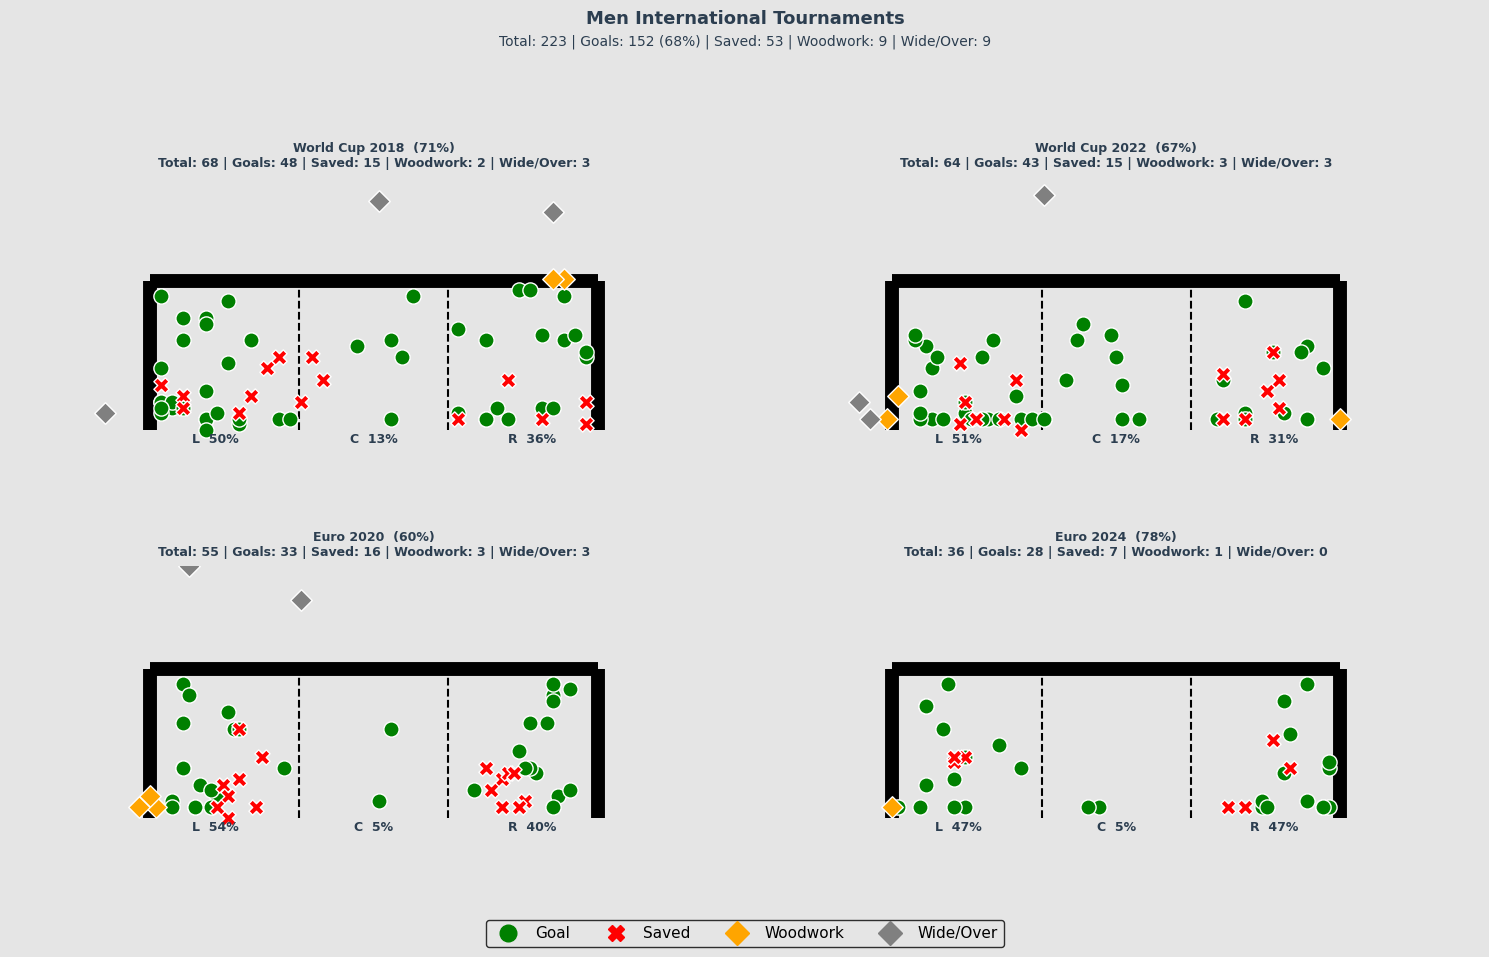

In [32]:
fig_men = plot_gender_penalties(penalties_by_tournament, "Men", men_labels, men_display)

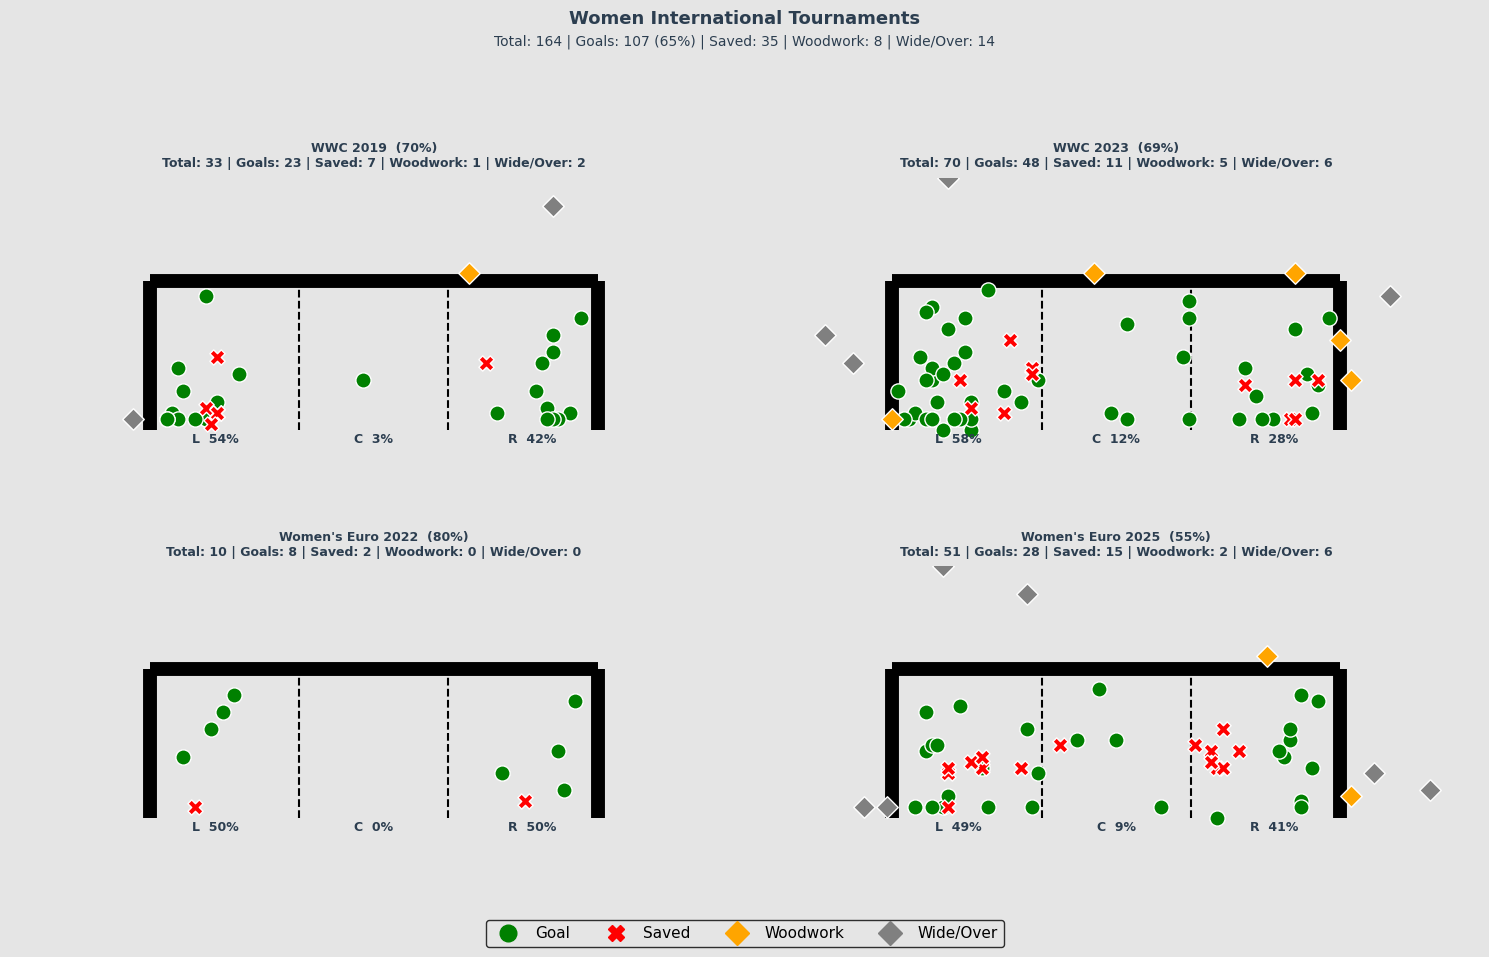

In [33]:
fig_women = plot_gender_penalties(penalties_by_tournament, "Women", women_labels, women_display)

### Filter by in-game vs shootouts

In [34]:
def filter_by_period(penalties_by_tournament, in_game=True):
    """Return new dict filtered to in-game (period != 5) or shootout (period == 5)."""
    filtered = {}
    for label, df in penalties_by_tournament.items():
        if df.empty:
            filtered[label] = df
            continue
        mask = df['period'] != 5 if in_game else df['period'] == 5
        filtered[label] = df[mask].reset_index(drop=True)
    return filtered

In [35]:
penalties_in_game = filter_by_period(penalties_by_tournament, in_game=True)

In [36]:
penalties_shootout = filter_by_period(penalties_by_tournament, in_game=False)

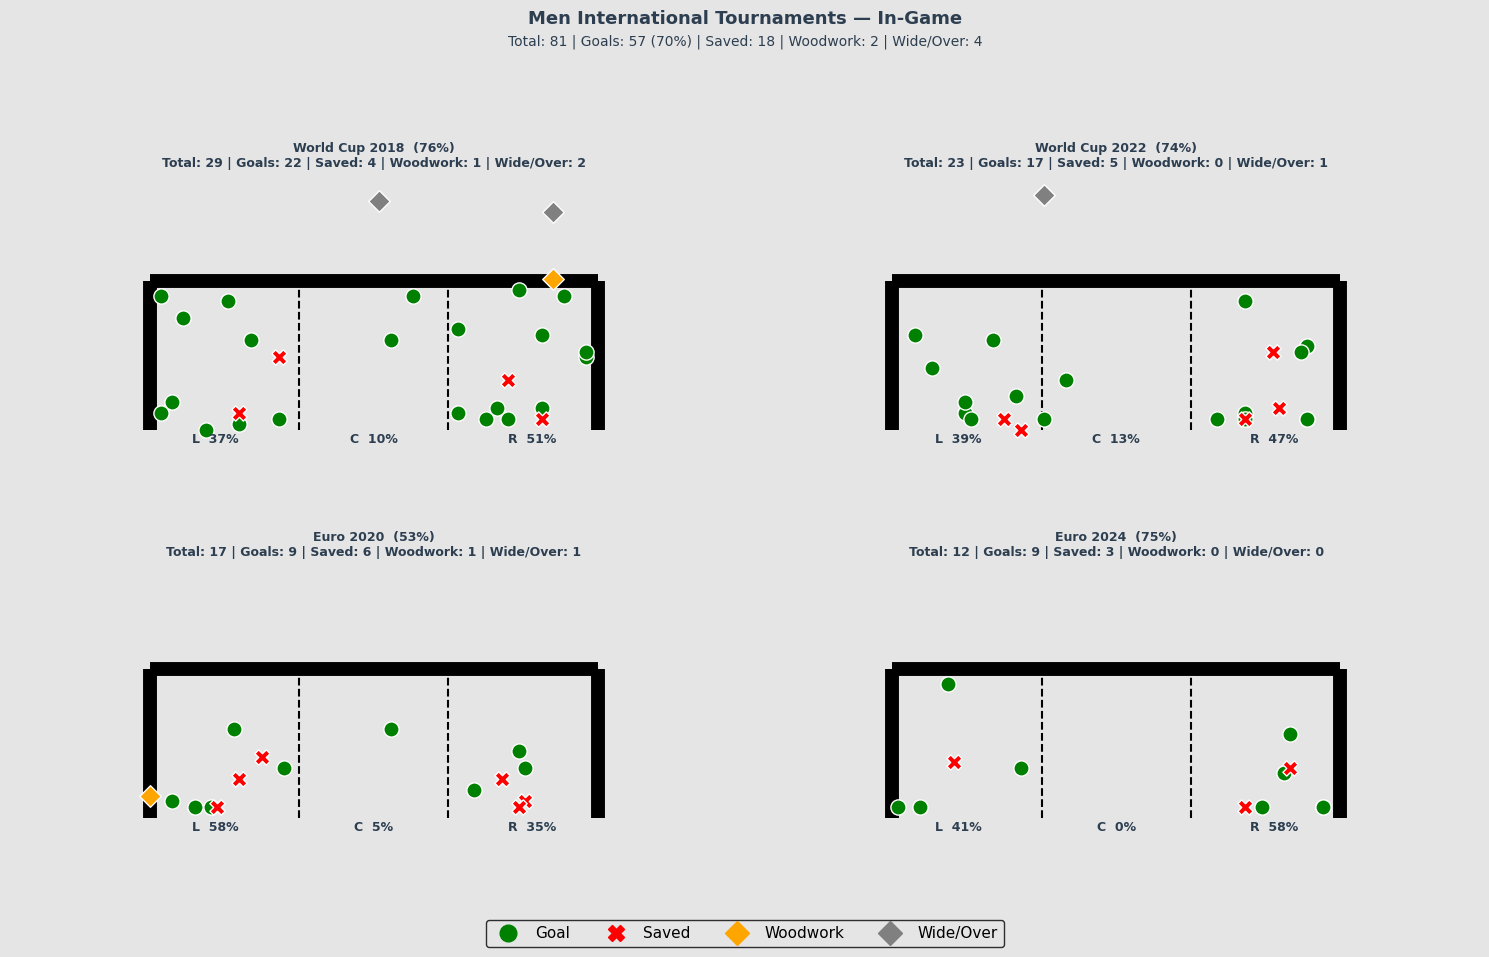

In [37]:
fig_men_in_game  = plot_gender_penalties(penalties_in_game, "Men", men_labels, men_display, subtitle="In-Game")

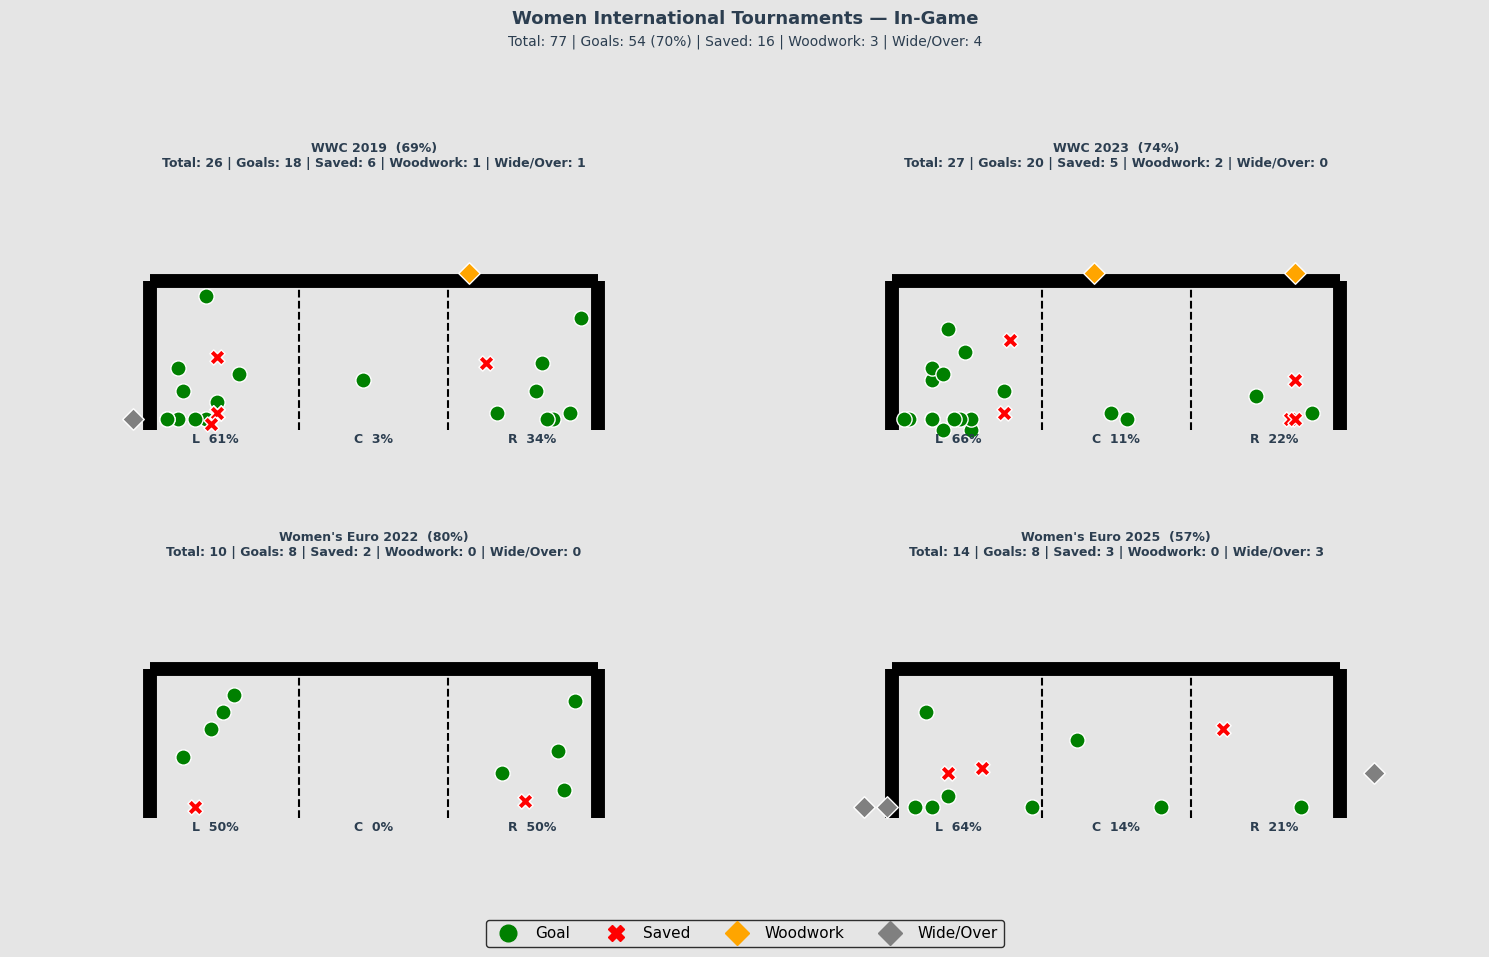

In [38]:
fig_women_in_game = plot_gender_penalties(penalties_in_game, "Women", women_labels, women_display, subtitle="In-Game")

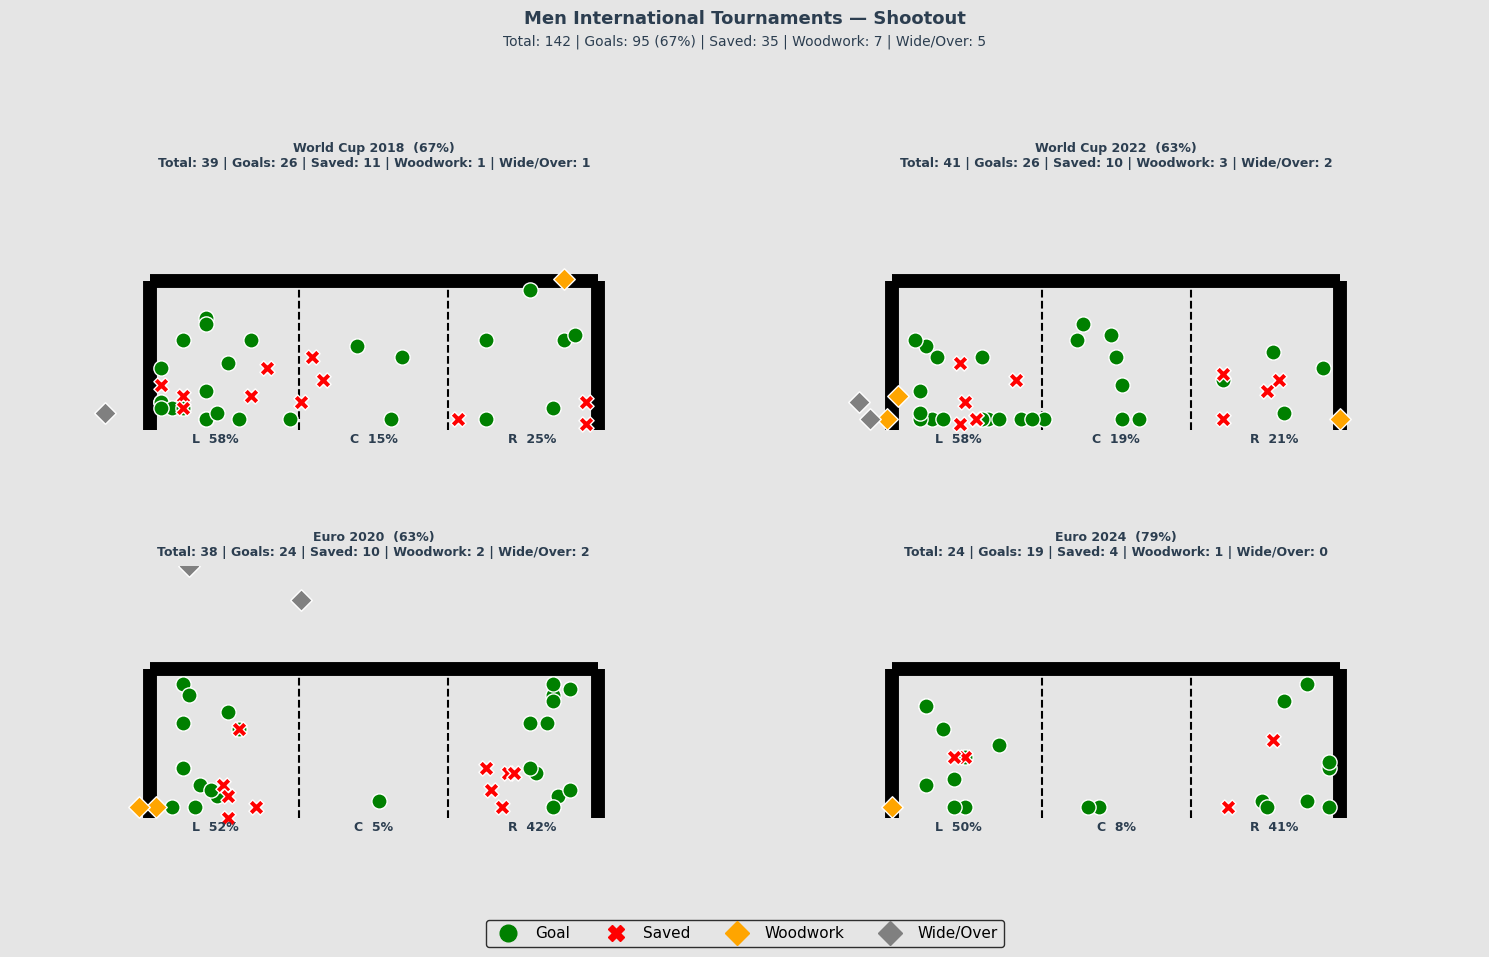

In [39]:
fig_men_shootout   = plot_gender_penalties(penalties_shootout, "Men", men_labels, men_display, subtitle="Shootout")

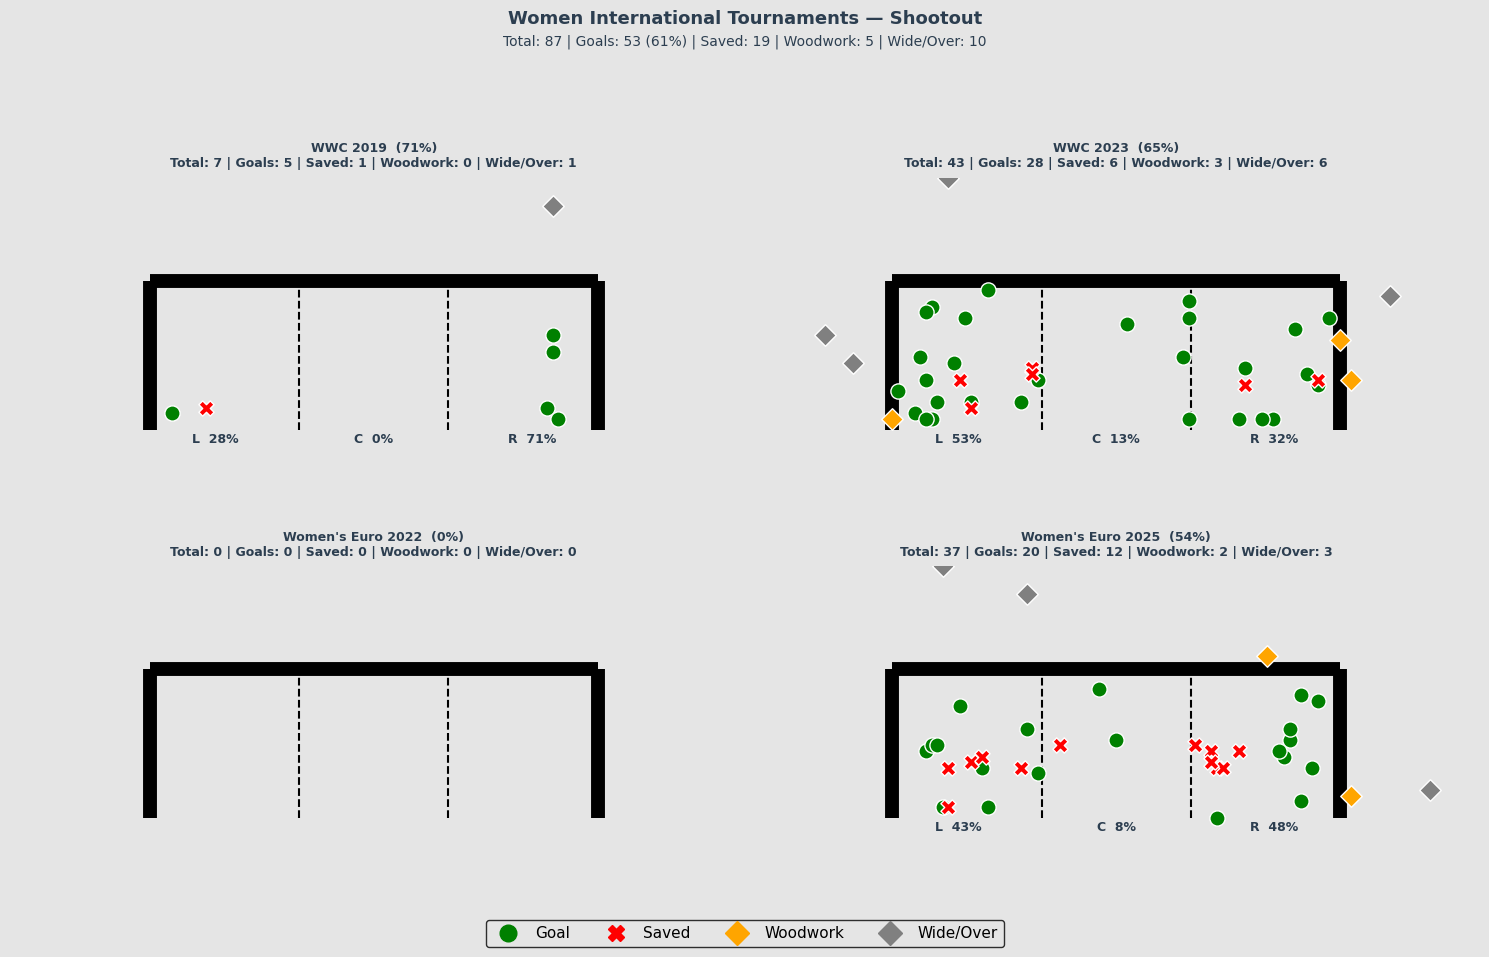

In [40]:
fig_women_shootout = plot_gender_penalties(penalties_shootout, "Women", women_labels, women_display, subtitle="Shootout")

### Plot by foot

In [41]:
def filter_by_foot(penalties_by_tournament, foot):
    """Return new dict filtered to a specific shot_body_part_name ('Left Foot' or 'Right Foot')."""
    filtered = {}
    for label, df in penalties_by_tournament.items():
        if df.empty:
            filtered[label] = df
            continue
        bp_col = 'shot_body_part' if 'shot_body_part' in df.columns else 'shot_body_part_name'
        filtered[label] = df[df[bp_col] == foot].reset_index(drop=True)
    return filtered

In [42]:
penalties_left_foot  = filter_by_foot(penalties_by_tournament, "Left Foot")

In [43]:
penalties_right_foot = filter_by_foot(penalties_by_tournament, "Right Foot")

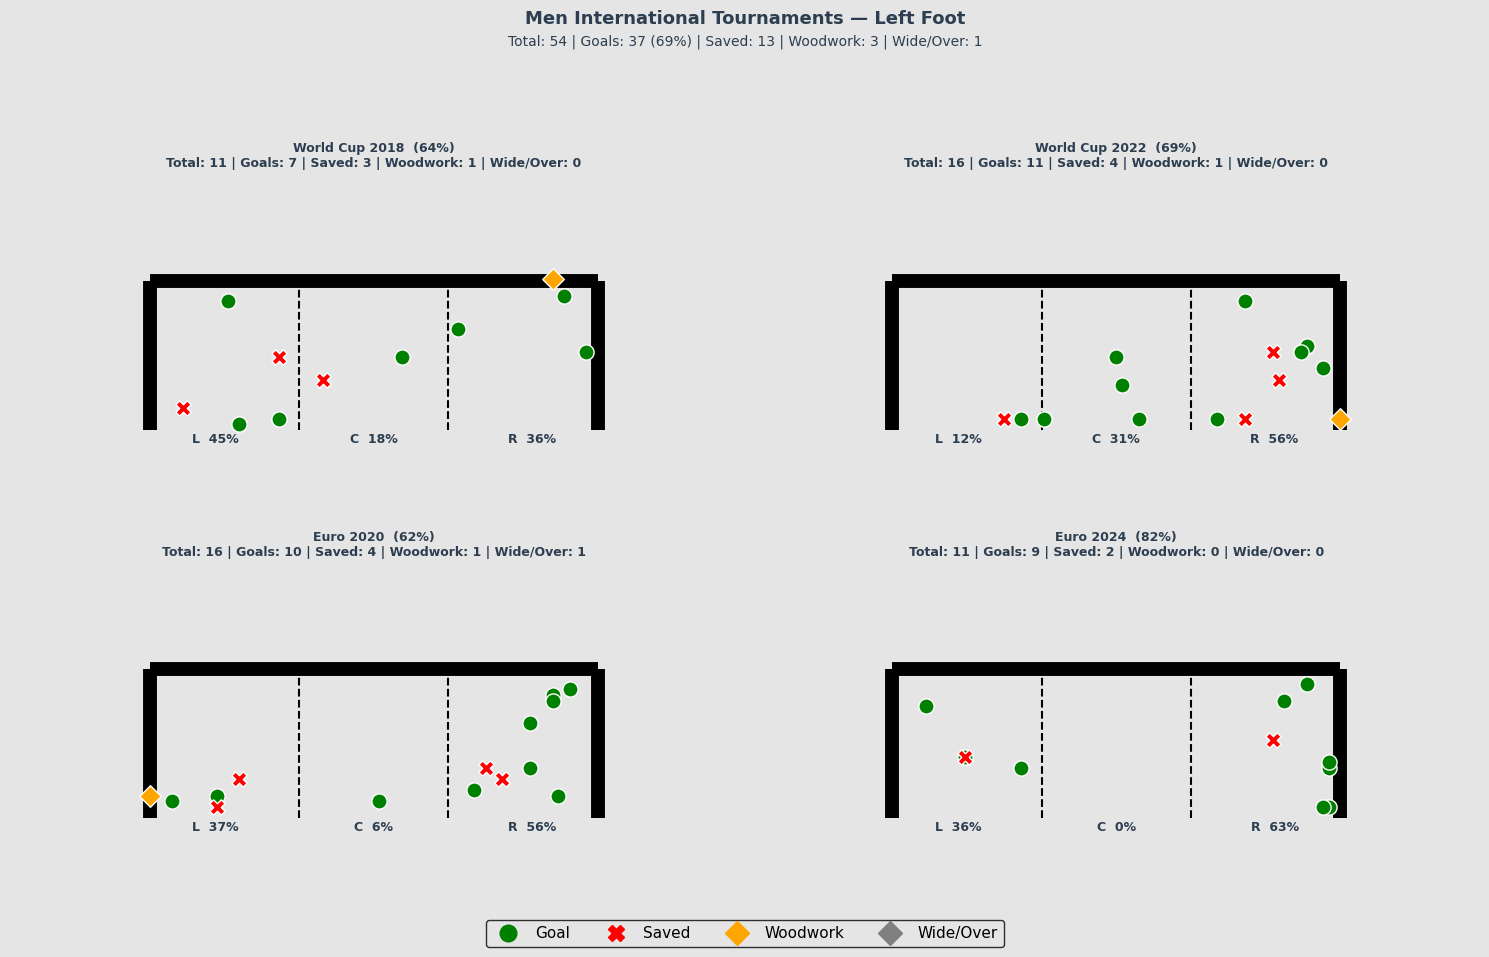

In [44]:
fig_men_left = plot_gender_penalties(penalties_left_foot, "Men", men_labels, men_display,subtitle="Left Foot")

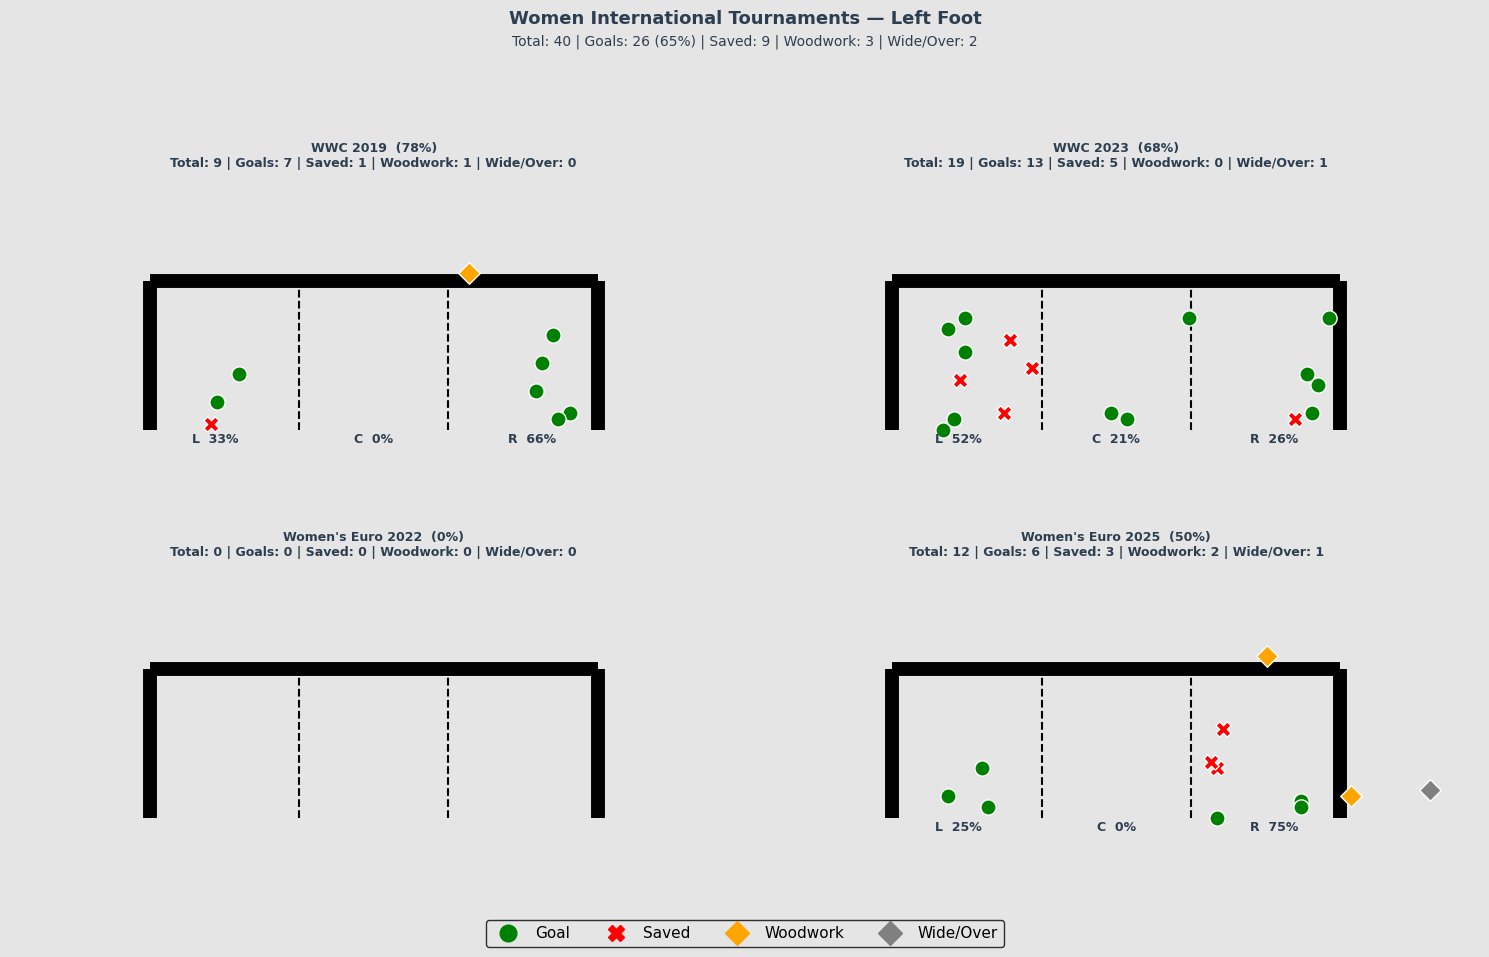

In [45]:
fig_women_left = plot_gender_penalties(penalties_left_foot, "Women", women_labels, women_display, subtitle="Left Foot")

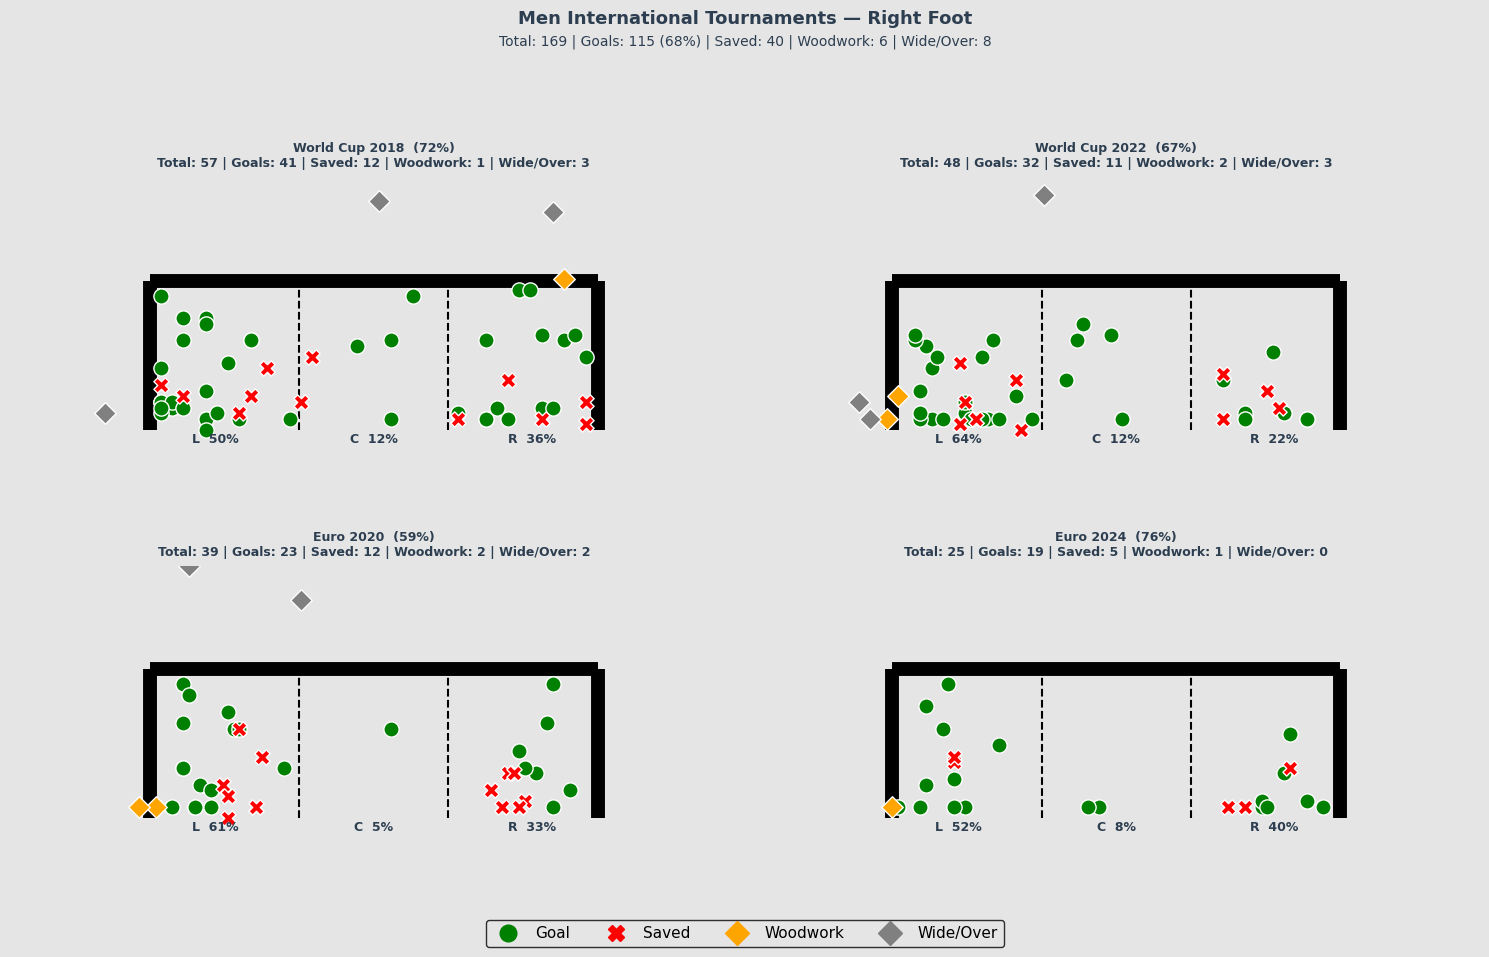

In [46]:
fig_men_right = plot_gender_penalties(penalties_right_foot, "Men", men_labels, men_display, subtitle="Right Foot")

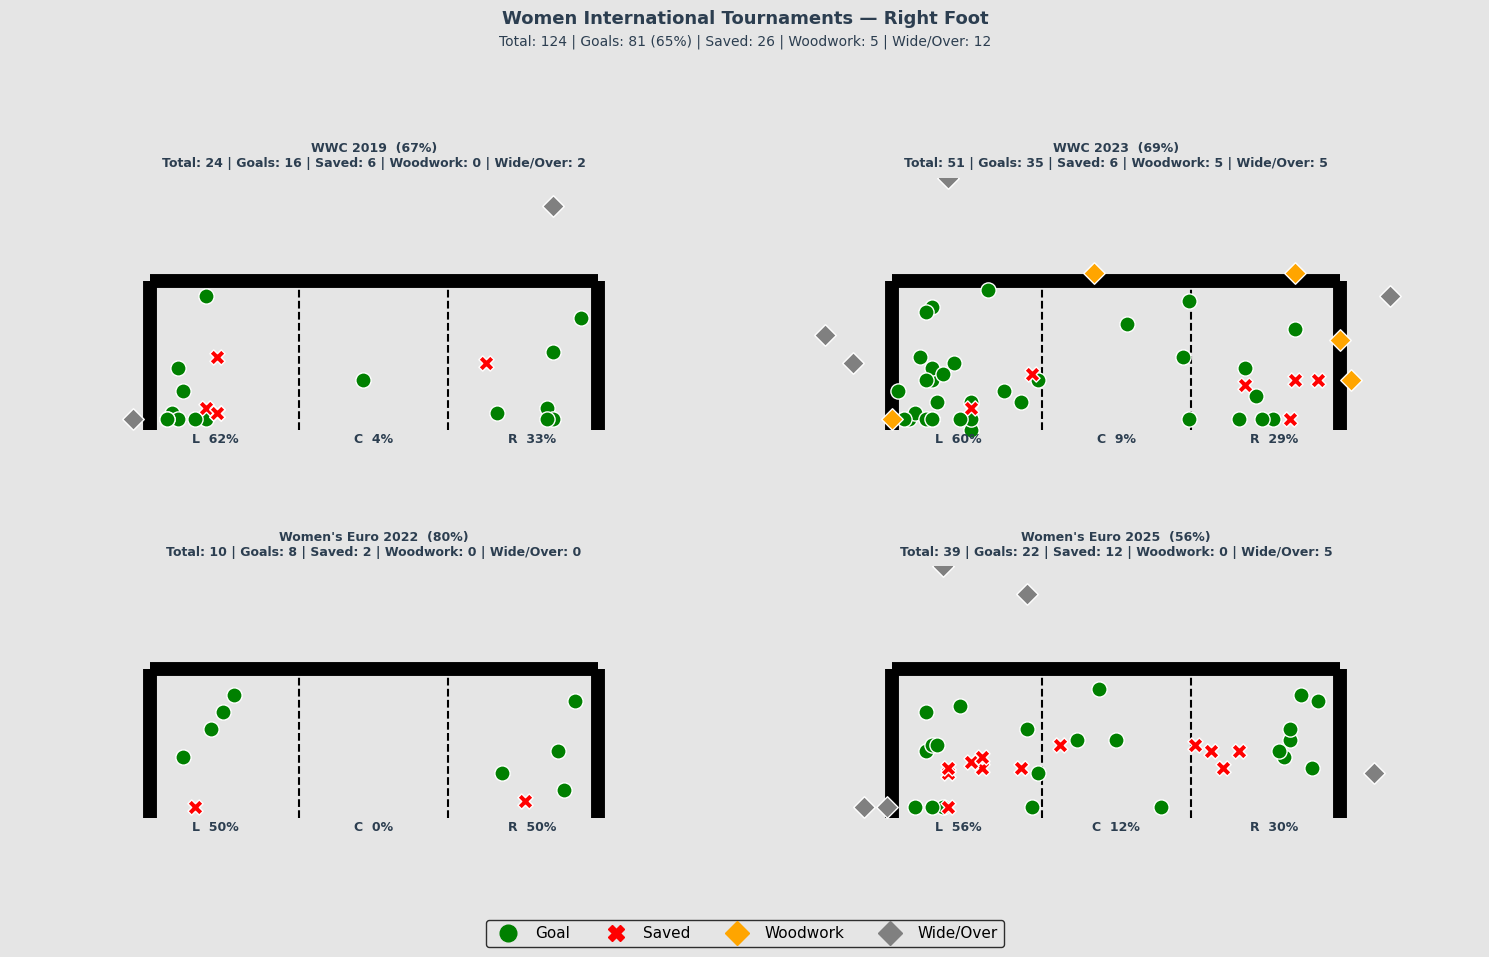

In [47]:
fig_women_right = plot_gender_penalties(penalties_right_foot, "Women", women_labels, women_display, subtitle="Right Foot")

### Filter by minute buckets for regular time and extra time penalties

In [48]:
def classify_minute_bucket(period, minute):
    if period == 1:
        if minute < 15:
            return '0-15'
        elif minute < 30:
            return '15-30'
        else:
            return '30-45+'    # covers stoppage time naturally
    elif period == 2:
        if minute < 60:
            return '45-60'
        elif minute < 75:
            return '60-75'
        else:
            return '75-90+'    # covers stoppage time naturally
    elif period == 3:
        return 'ET 1st Half'
    elif period == 4:
        return 'ET 2nd Half'
    else:
        return 'Other'

In [49]:
for df in penalties_by_tournament.values():
    if df.empty:
        continue
    df['minute_bucket'] = df.apply(
        lambda r: classify_minute_bucket(r['period'], r['minute'])
        if r['period'] != 5 else 'Shootout',
        axis=1
    )

In [50]:
minute_bucket_order = [
    '0-15', '15-30', '30-45+',
    '45-60', '60-75', '75-90+',
    'ET 1st Half', 'ET 2nd Half'
]

In [81]:
def plot_gender_by_minute(penalties_by_tournament, gender, labels, subtitle=""):
    df_gender = combine_gender(penalties_by_tournament, labels)
    df_ingame = df_gender[df_gender['period'] != 5]

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()
    fig.patch.set_facecolor(bg_color)

    for ax, bucket in zip(axes, minute_bucket_order):
        df_bucket = df_ingame[df_ingame['minute_bucket'] == bucket]
        plot_tournament_ax(ax, df_bucket, bucket)

    fig.suptitle(
        f"{gender} International Tournaments — Penalties by Minute"
        + (f" — {subtitle}" if subtitle else ""),
        fontsize=13, fontweight='bold', color='#2c3e50', y=1.04
    )

    # Overall in-game stats as subtitle
    n_goals    = (df_ingame['outcome_class'] == 'Goal').sum()
    n_total    = len(df_ingame)
    n_saved    = (df_ingame['outcome_class'] == 'Saved').sum()
    n_woodwork = (df_ingame['outcome_class'] == 'Woodwork').sum()
    n_miss     = (df_ingame['outcome_class'] == 'Wide/Over').sum()
    pct        = n_goals / n_total * 100 if n_total else 0

    fig.text(
        0.5, 1.00,
        f"Total: {n_total} | Goals: {n_goals} ({pct:.0f}%) | "
        f"Saved: {n_saved} | Woodwork: {n_woodwork} | Wide/Over: {n_miss}",
        ha='center', fontsize=10, color='#2c3e50'
    )

    legend_handles = [
        Line2D([0], [0], ls='None', color=v['color'], marker=v['marker'], markersize=12)
        for v in outcome_styles.values()
    ]
    fig.legend(legend_handles, list(outcome_styles.keys()),
            fontsize=11, ncol=4, loc='lower center',
            bbox_to_anchor=(0.5, -0.01),
            edgecolor='black', facecolor=bg_color)

    plt.tight_layout()
    fig.savefig(
        f"penalties_by_minute_{gender.lower()}"
        + (f"_{subtitle.lower().replace(' ', '_')}" if subtitle else "") + ".png",
        dpi=150, bbox_inches='tight', facecolor=bg_color
    )
    plt.show()
    return fig

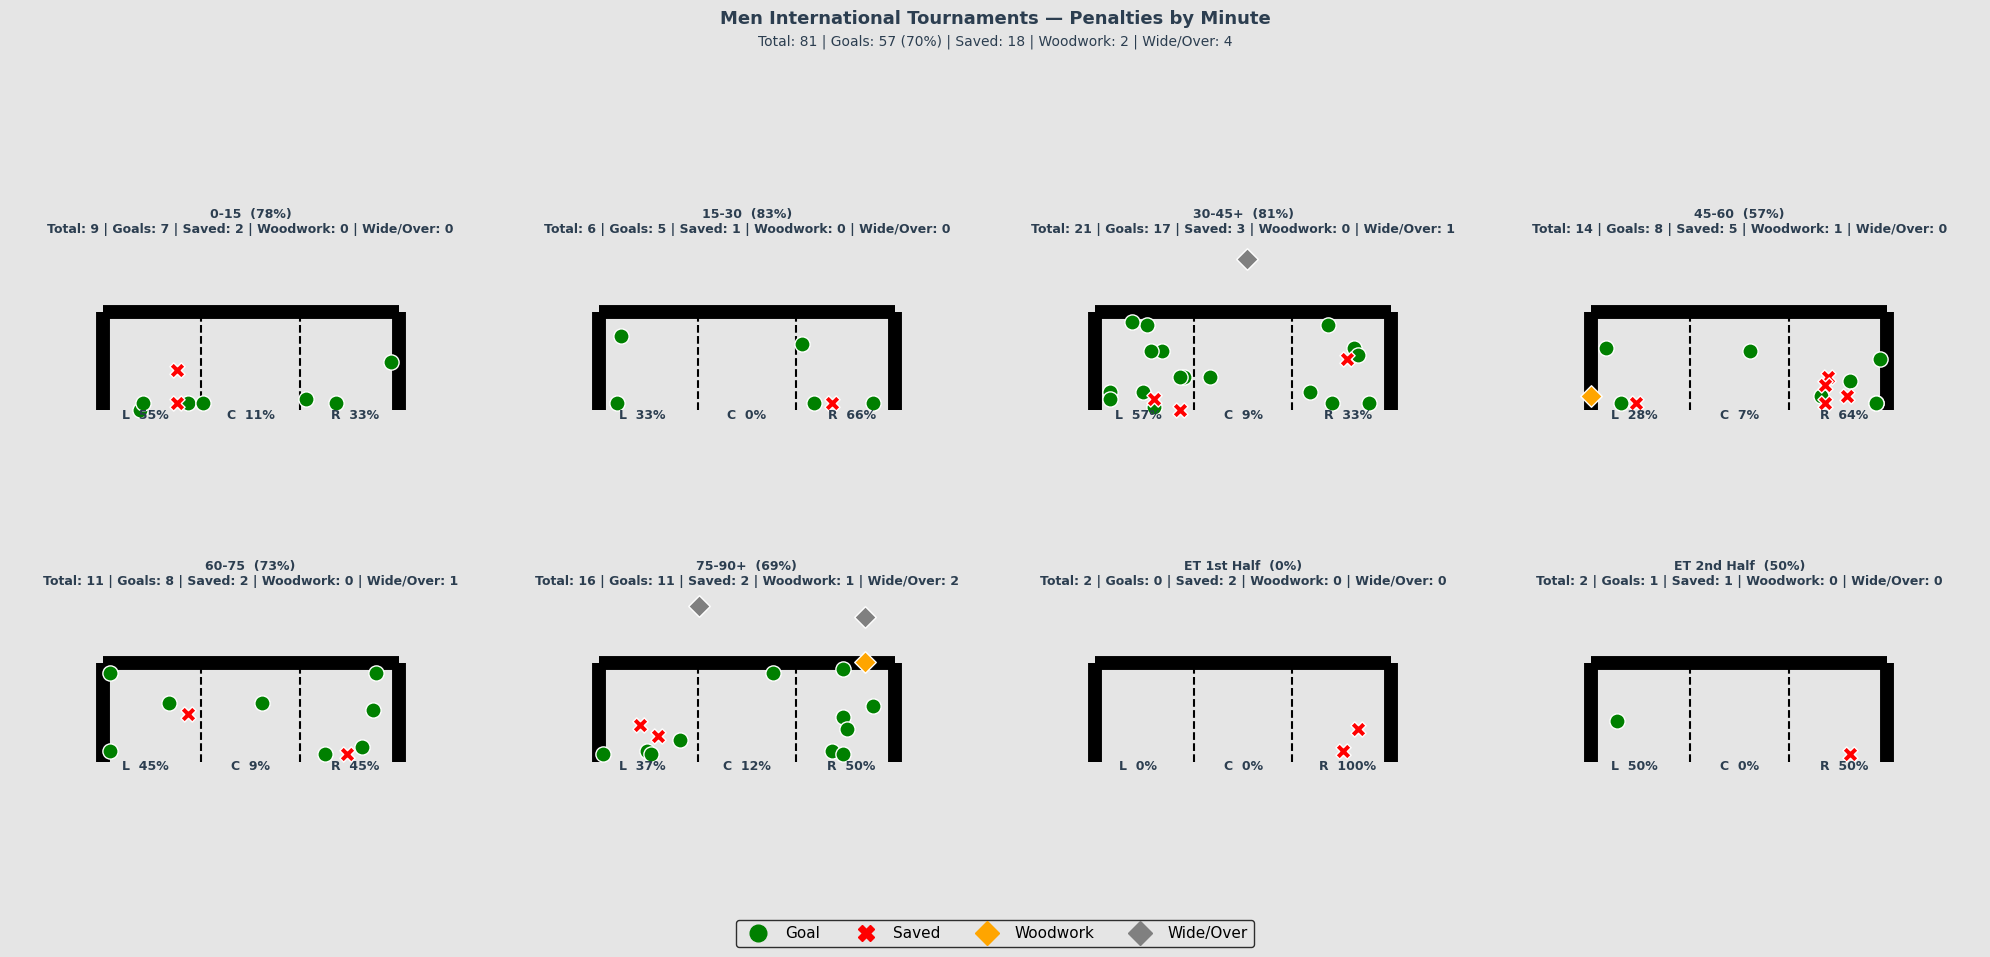

In [82]:
fig_men_minute = plot_gender_by_minute(penalties_by_tournament, "Men", men_labels)

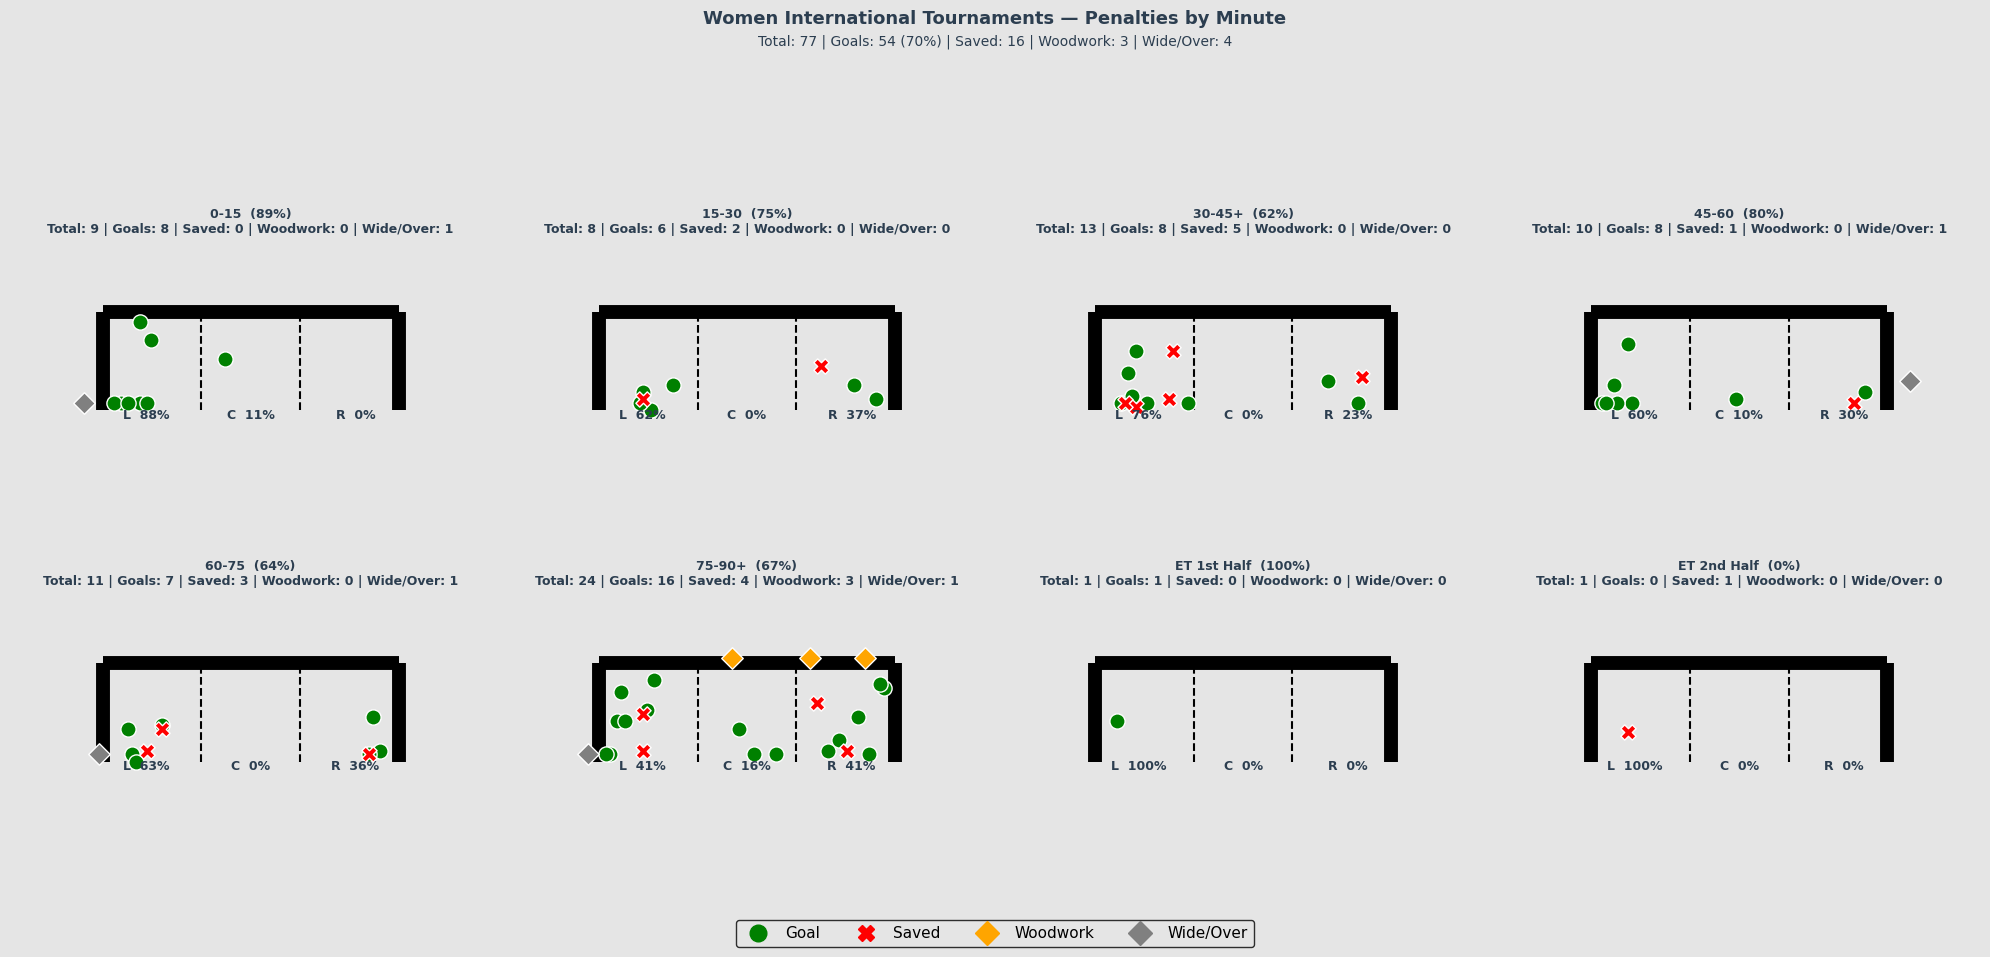

In [83]:
fig_women_minute = plot_gender_by_minute(penalties_by_tournament, "Women", women_labels)

In [61]:
df_men = combine_gender(penalties_by_tournament, men_labels)

In [62]:
df_men_ingame = df_men[df_men['period'] != 5]

In [63]:
df_men_et1 = df_men_ingame[df_men_ingame['minute_bucket'] == 'ET 1st Half']

In [65]:
df_men_et1

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_outcome,shot_body_part,shot_type,shot_technique,shot_freeze_frame,possession_team_id,team_id,player_id,shot_key_pass_id,shot_first_time,under_pressure,shot_one_on_one,shot_aerial_won,gender,shot_open_goal,shot_deflected,shot_redirect,shot_follows_dribble,end_x,end_y,end_z,outcome_class,zone_6,minute_bucket,out,shot_saved_to_post,shot_saved_off_target,off_camera
171,8b9704bd-00b9-4102-bffd-a1283462031d,3891,3,00:13:41.592,103,41,Shot,178,England,Other,England,Harry Kane,Center Forward,"[108.1, 40.1]",0.392549,[55bcc60b-a128-4f1c-ae8f-1580f0bc08a7],3795221,0.7835,"[119.2, 42.7, 0.3]",Saved,Right Foot,Penalty,Normal,NaN,768,768,10955,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,119.2,42.7,0.3,Saved,Bot Right,ET 1st Half,NaN,NaN,NaN,NaN
213,c313018b-a497-4500-96f7-984c20d7a63d,3694,3,00:14:50.595,104,50,Shot,184,Portugal,Other,Portugal,Cristiano Ronaldo dos Santos Aveiro,Center Forward,"[108.1, 40.1]",0.301081,[e531667d-5607-43e4-aed2-c0a7930320f8],3941020,0.7835,"[119.7, 43.1, 0.9]",Saved to Post,Right Foot,Penalty,Normal,NaN,780,780,5207,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,119.7,43.1,0.9,Saved,Bot Right,ET 1st Half,NaN,True,NaN,NaN


In [66]:
df_men_et2 = df_men_ingame[df_men_ingame['minute_bucket'] == 'ET 2nd Half']

In [67]:
df_men_et2

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_outcome,shot_body_part,shot_type,shot_technique,shot_freeze_frame,possession_team_id,team_id,player_id,shot_key_pass_id,shot_first_time,under_pressure,shot_one_on_one,shot_aerial_won,gender,shot_open_goal,shot_deflected,shot_redirect,shot_follows_dribble,end_x,end_y,end_z,outcome_class,zone_6,minute_bucket,out,shot_saved_to_post,shot_saved_off_target,off_camera
23,94b78e58-6698-43ee-be7f-c4995aae88ea,4046,4,00:10:47.336,115,47,Shot,207,Croatia,Other,Croatia,Luka Modrić,Left Defensive Midfield,"[109.0, 41.0]",0.578000,[f55229c1-a838-466e-a3b9-3dc50fea9473],7581,0.7835,"[119.0, 43.0, 0.2]",Saved,Right Foot,Penalty,Normal,NaN,785,785,5463,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,119.0,43.0,0.2,Saved,Bot Right,ET 2nd Half,NaN,NaN,NaN,NaN
88,d9b92dbd-4fea-4f48-b2fb-d7222eab2dbd,4203,4,00:12:05.189,117,5,Shot,238,France,Other,France,Kylian Mbappé Lottin,Left Center Forward,"[108.0, 40.0]",0.406482,[7702c4cb-e5ea-4353-9e70-6df2eead4987],3869685,0.7835,"[120.0, 36.7, 1.1]",Goal,Right Foot,Penalty,Normal,NaN,771,771,3009,NaN,NaN,NaN,NaN,NaN,male,NaN,NaN,NaN,NaN,120.0,36.7,1.1,Goal,Bot Left,ET 2nd Half,NaN,NaN,NaN,NaN


In [68]:
df_women = combine_gender(penalties_by_tournament, women_labels)

In [69]:
df_women_ingame = df_women[df_women['period'] != 5]

In [79]:
df_women_0_15 = df_women_ingame[df_women_ingame['minute_bucket'] == '0-15']

In [80]:
df_women_0_15

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_body_part,shot_type,shot_outcome,shot_technique,shot_freeze_frame,possession_team_id,team_id,player_id,shot_first_time,shot_saved_to_post,out,under_pressure,shot_aerial_won,gender,shot_deflected,shot_one_on_one,shot_open_goal,shot_saved_off_target,off_camera,shot_redirect,shot_kick_off,shot_follows_dribble,end_x,end_y,end_z,outcome_class,zone_6,minute_bucket
2,9c86376d-a10b-4fda-8682-1fada8c1d935,356,1,00:11:49.939,11,49,Shot,21,Italy Women's,Other,Italy Women's,Cristiana Girelli,Center Attacking Midfield,"[108.1, 40.1]",0.577300,[5632e514-5137-428c-a3c2-2851d2a2206e],22963,0.7835,"[120.0, 37.0, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,NaN,855,855,10203,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,37.0,0.2,Goal,Bot Left,0-15
22,bf8041b8-3500-4086-aacb-11127d2f5329,503,1,00:13:06.245,13,6,Shot,24,England Women's,Other,England Women's,Nikita Parris,Right Midfield,"[108.0, 39.9]",0.624900,[53773957-edd1-4fc6-a861-2c7eb4b54324],22936,0.7835,"[120.0, 37.0, 2.4]",NaN,Right Foot,Penalty,Goal,Normal,NaN,865,865,4654,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,37.0,2.4,Goal,Top Left,0-15
24,4445056d-0f8c-401f-975b-6ceb99f0c6ea,116,1,00:04:34.404,4,34,Shot,9,Norway Women's,Other,Norway Women's,Caroline Graham Hansen,Right Midfield,"[108.1, 40.1]",0.606993,[8324c748-2054-44e1-b3a4-5e7e86ad0876],22981,0.7835,"[120.0, 36.5, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,NaN,852,852,10386,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,36.5,0.2,Goal,Bot Left,0-15
31,06ff8eb5-0dab-4d26-acd0-8980a0492d98,199,1,00:06:06.236,6,6,Shot,12,United States Women's,Other,United States Women's,Megan Anna Rapinoe,Left Wing,"[108.1, 40.1]",0.496300,[279b37a2-88d8-4554-90bc-a00a2cca0816],69161,0.7835,"[120.0, 36.3, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,NaN,1214,1214,8298,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,36.3,0.2,Goal,Bot Left,0-15
65,81b19e73-5711-4ad9-aca2-b847c2fafe83,438,1,00:10:54.894,10,54,Shot,26,Italy Women's,Other,Italy Women's,Arianna Caruso,Right Defensive Midfield,"[108.1, 40.1]",0.545914,[66c18ee1-6e0e-494b-8c89-4b2e2dec7d70],3893831,0.7835,"[120.0, 37.2, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,NaN,855,855,32162,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,37.2,0.2,Goal,Bot Left,0-15
106,fc024ff5-92e9-4722-8c19-b249e969578d,448,1,00:11:05.568,11,5,Shot,29,England Women's,Other,England Women's,Georgia Stanway,Right Center Midfield,"[108.0, 40.0]",0.498022,[abf6ca5c-58d3-4696-a8ea-ae88a86305c8],3835327,0.7835,"[120.0, 37.3, 1.9]",NaN,Right Foot,Penalty,Goal,Normal,NaN,865,865,4643,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,37.3,1.9,Goal,Top Left,0-15
125,cae8a833-1faf-4a56-9a1c-34e85a53eeb1,379,1,00:14:14.644,14,14,Shot,20,France Women's,Other,France Women's,Onema Grace Geyoro,Right Center Midfield,"[108.1, 40.1]",0.641478,[4865a94c-bb86-4d66-9e09-85c5b5863e7f],4018357,0.7835,"[120.0, 39.3, 1.4]",NaN,Right Foot,Penalty,Goal,Normal,NaN,861,861,10272,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,39.3,1.4,Goal,Top Centre,0-15
141,3d121017-e9a2-4bf7-b154-0538d0996b87,358,1,00:08:02.455,8,2,Shot,17,Spain Women's,Other,Spain Women's,María Francesca Caldentey Oliver,Right Wing,"[108.0, 40.0]",0.588135,[9754ba8e-75dd-43ee-92c3-b1bba0464e61],4018356,0.7835,"[120.0, 35.5, 0.2]",NaN,Right Foot,Penalty,Off T,Normal,"[{'location': [119.0, 40.1], 'player': {'id': ...",863,863,10161,NaN,NaN,NaN,NaN,NaN,female,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,120.0,35.5,0.2,Wide/Over,Bot Left,0-15
158,7b8cab3a-c66c-404d-a276-35046bbb3421,368,1,00:12:41.068,12,41,Shot,22,England Women's,Other,England Women's,Georgia Stanway,Left Center Midfield,"[108.0, 40.0]",0.574043,[87bc3072-dee8-44a3-8450-848c32ea92c6],3998858,0.7835,"[120.0

In [74]:
df_women_30_45 = df_women_ingame[df_women_ingame['minute_bucket'] == '30-45+']

In [75]:
df_women_30_45

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_body_part,shot_type,shot_outcome,shot_technique,shot_freeze_frame,possession_team_id,team_id,player_id,shot_first_time,shot_saved_to_post,out,under_pressure,shot_aerial_won,gender,shot_deflected,shot_one_on_one,shot_open_goal,shot_saved_off_target,off_camera,shot_redirect,shot_kick_off,shot_follows_dribble,end_x,end_y,end_z,outcome_class,zone_6,minute_bucket
17,bc04225d-f671-4fe9-a0f6-580d92c9faff,1471,1,00:36:30.453,36,30,Shot,67,Japan Women's,Other,Japan Women's,Yuika Sugasawa,Right Center Forward,"[108.1, 40.1]",0.738300,[b654ca0e-d775-406d-88a8-1690a026aa02],22961,0.7835,"[120.0, 43.1, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,"[{'location': [119.5, 40.1], 'player': {'id': ...",1210,1210,25637,NaN,NaN,NaN,NaN,NaN,female,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,120.0,43.1,0.2,Goal,Bot Right,30-45+
29,2864ccf8-c400-4fff-85a0-635792d2f989,1244,1,00:37:55.484,37,55,Shot,76,Brazil Women's,Other,Brazil Women's,Andressa Alves da Silva,Right Midfield,"[107.9, 40.0]",0.458000,[c4e5493a-7842-4372-abea-017c55703387],22934,0.7835,"[118.9, 37.1, 0.1]",NaN,Left Foot,Penalty,Saved,Normal,NaN,1203,1203,24368,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.9,37.1,0.1,Saved,Bot Left,30-45+
33,56fcfa0d-3fc8-4458-832f-33bb66b8ed3b,1693,1,00:48:36.755,48,36,Shot,99,Morocco Women's,Other,Morocco Women's,Ghizlane Chebbak,Left Defensive Midfield,"[108.1, 40.1]",0.487585,[029e5a26-b1a1-4dd0-aebc-74043a826068],3893834,0.7835,"[119.4, 43.2, 0.9]",NaN,Right Foot,Penalty,Saved,Normal,NaN,2391,2391,402663,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.4,43.2,0.9,Saved,Bot Right,30-45+
36,0868f6f6-0255-48c4-b3ef-ae06fdc94a09,1052,1,00:36:45.501,36,45,Shot,63,France Women's,Other,France Women's,Kadidiatou Diani,Center Forward,"[108.1, 40.1]",0.503174,[111ff234-cd55-4ce0-8389-0324dabdfc9f],3893829,0.7835,"[120.0, 36.7, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,NaN,861,861,10137,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,36.7,0.2,Goal,Bot Left,30-45+
62,bfb5d5f1-f1c2-41ef-bcb8-9232f03c9ee9,1041,1,00:30:37.035,30,37,Shot,52,Zambia W,Other,Zambia W,Barbra Banda,Center Forward,"[108.1, 40.1]",0.485540,[7db2231b-c044-494d-9f3c-276e83ef3543],3893823,0.7835,"[120.0, 37.4, 0.2]",NaN,Right Foot,Penalty,Goal,Normal,NaN,6045,6045,131619,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,37.4,0.2,Goal,Bot Left,30-45+
67,39d31cb5-3165-456c-a1b6-cc06cd7588b0,1211,1,00:33:56.673,33,56,Shot,51,Spain Women's,Other,Spain Women's,Jennifer Hermoso Fuentes,Left Center Midfield,"[108.1, 40.1]",0.532408,[c86612b9-8890-490c-921b-d1668bbd3f5c],3893791,0.7835,"[119.4, 38.1, 1.6]",NaN,Left Foot,Penalty,Saved,Normal,NaN,863,863,10151,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.4,38.1,1.6,Saved,Top Left,30-45+
99,35645278-beb7-4033-a91b-5fecc215dbc8,1728,1,00:44:54.832,44,54,Shot,71,Switzerland Women's,Other,Switzerland Women's,Ramona Bachmann,Left Wing,"[108.1, 40.1]",0.805429,[c6485c4a-91c9-4000-8e94-749d45f86085],3893789,0.7835,"[120.0, 36.9, 1.0]",NaN,Right Foot,Penalty,Goal,Normal,NaN,860,860,4659,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,36.9,1.0,Goal,Bot Left,30-45+
101,6b36395e-58f5-45eb-a54a-9da643414feb,1205,1,00:43:23.404,43,23,Shot,76,United States Women's,Other,United States Women's,Alexandra Morgan Carrasco,Center Forward,"[107.8, 40.0]",0.450437,[56424bfb-44b3-40e4-ba0c-e2edb7e30456],3893792,0.7835,"[119.1, 38.0, 0.3]",NaN,Left Foot,Penalty,Saved,Normal,NaN,1214,1214,5085,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.1,38.0,0.3,Saved,Bot Left,30-45+
103,16980838-c677-4d74-b3ad-56b6b9aa4d11,899,1,00:30:50.020,30,50,Shot,56,Norway Women's,Other,Norway Women's,Caroline Graham Hansen,Center Attacking Midfield,"[108.1, 40.1]",0.743107,[b7a33005-10fc-4583-95

In [70]:
df_women_et1 = df_women_ingame[df_women_ingame['minute_bucket'] == 'ET 1st Half']

In [72]:
df_women_et1

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_body_part,shot_type,shot_outcome,shot_technique,shot_freeze_frame,possession_team_id,team_id,player_id,shot_first_time,shot_saved_to_post,out,under_pressure,shot_aerial_won,gender,shot_deflected,shot_one_on_one,shot_open_goal,shot_saved_off_target,off_camera,shot_redirect,shot_kick_off,shot_follows_dribble,end_x,end_y,end_z,outcome_class,zone_6,minute_bucket
108,3d66c25b-e7ac-4b3f-9bc0-c4b12be4f3a9,3726,3,00:11:21.602,101,21,Shot,194,France Women's,Other,France Women's,Eve Perisset,Right Back,"[108.0, 40.0]",0.462843,[7ba639bc-9dad-439a-9f7b-1ee4ce921c2e],3844387,0.7835,"[120.0, 36.6, 1.1]",NaN,Right Foot,Penalty,Goal,Normal,NaN,861,861,10418,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,36.6,1.1,Goal,Bot Left,ET 1st Half


In [71]:
df_women_et2 = df_women_ingame[df_women_ingame['minute_bucket'] == 'ET 2nd Half']

In [73]:
df_women_et2

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_body_part,shot_type,shot_outcome,shot_technique,shot_freeze_frame,possession_team_id,team_id,player_id,shot_first_time,shot_saved_to_post,out,under_pressure,shot_aerial_won,gender,shot_deflected,shot_one_on_one,shot_open_goal,shot_saved_off_target,off_camera,shot_redirect,shot_kick_off,shot_follows_dribble,end_x,end_y,end_z,outcome_class,zone_6,minute_bucket
124,6dc0cc50-98f6-4233-8173-7e4c36413c76,4051,4,00:13:50.866,118,50,Shot,227,England Women's,Other,England Women's,Chloe Kelly,Right Midfield,"[108.1, 40.1]",0.439349,[94dce8ac-6d14-4b5b-b05c-0b0b7dfa2115],4020005,0.7835,"[119.4, 37.0, 0.8]",NaN,Right Foot,Penalty,Saved,Normal,NaN,865,865,15570,NaN,NaN,NaN,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.4,37.0,0.8,Saved,Bot Left,ET 2nd Half


## Plot by zone

In [84]:
def plot_zone_heatmap_ax(ax, df, display_name):
    ax.set_facecolor(bg_color)

    total    = len(df)
    n_goals  = (df['outcome_class'] == 'Goal').sum()
    pct      = n_goals / total * 100 if total else 0

    # Find max shots in any zone for colour scaling
    zone_counts = df['zone_6'].value_counts()
    max_count   = zone_counts.max() if not zone_counts.empty else 1

    for zone, (y0, y1, z0, z1) in zone_6_coords.items():
        zone_df    = df[df['zone_6'] == zone]
        n_zone     = len(zone_df)
        n_zone_g   = (zone_df['outcome_class'] == 'Goal').sum()
        conv       = n_zone_g / n_zone * 100 if n_zone else 0
        intensity  = n_zone / max_count  # 0–1 for colour scaling

        rect = plt.Rectangle(
            (y0, z0), y1 - y0, z1 - z0,
            facecolor=plt.cm.Greens(0.2 + 0.6 * intensity),
            edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(rect)

        # Zone label: shots taken and conversion rate
        cx, cz = (y0 + y1) / 2, (z0 + z1) / 2
        ax.text(cx, cz + 0.18, f"{n_zone} shots", ha='center',
                va='center', fontsize=8, color='black', fontweight='bold', zorder=2)
        ax.text(cx, cz - 0.18, f"{conv:.0f}% conv", ha='center',
                va='center', fontsize=7.5, color='#2c3e50', zorder=2)

    # Goal posts and crossbar on top
    post_kw = dict(color=post_color, linewidth=8, zorder=3, solid_capstyle='butt')
    ax.plot([36, 36], [0, 2.44], **post_kw)
    ax.plot([44, 44], [0, 2.44], **post_kw)
    ax.plot([36, 44], [2.44, 2.44], **post_kw)
    # Mid-height divider
    ax.plot([36, 44], [1.22, 1.22], color=post_color, linewidth=1,
            linestyle='dashed', zorder=3)
    # Vertical zone dividers
    for x in [38.67, 41.33]:
        ax.plot([x, x], [0, 2.44], color=post_color, linewidth=1,
                linestyle='dashed', zorder=3)

    ax.set_xlim(34.5, 45.5)
    ax.set_ylim(-0.4, 3.0)
    ax.set_aspect('equal')
    ax.axis('off')

    ax.set_title(
        f"{display_name}  ({pct:.0f}%)\n"
        f"Total: {total} | Goals: {n_goals} | "
        f"Saved: {(df['outcome_class']=='Saved').sum()} | "
        f"Woodwork: {(df['outcome_class']=='Woodwork').sum()} | "
        f"Wide/Over: {(df['outcome_class']=='Miss').sum()}",
        fontsize=9, fontweight='bold', color='#2c3e50', pad=8
    )

In [85]:
def plot_gender_zones(penalties_by_tournament, gender, labels, display_names, subtitle=""):
    # fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    # axes = plt.subplots(2, 2, figsize=(12, 9))[1].flatten()
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    fig.patch.set_facecolor(bg_color)

    all_df      = pd.concat([penalties_by_tournament[l] for l in labels], ignore_index=True)
    total_goals = (all_df['outcome_class'] == 'Goal').sum()
    total_pens  = len(all_df)
    total_pct   = total_goals / total_pens * 100 if total_pens else 0
    n_saved     = (all_df['outcome_class'] == 'Saved').sum()
    n_woodwork  = (all_df['outcome_class'] == 'Woodwork').sum()
    n_miss      = (all_df['outcome_class'] == 'Wide/Over').sum()

    for ax, label, display in zip(axes, labels, display_names):
        plot_zone_heatmap_ax(ax, penalties_by_tournament[label], display)

    fig.suptitle(
        f"{gender} International Tournaments — 6-Zone Breakdown"
        + (f" — {subtitle}" if subtitle else ""),
        fontsize=13, fontweight='bold', color='#2c3e50', y=1.04
    )
    fig.text(
        0.5, 1.0,
        f"Total: {total_pens} | Goals: {total_goals} ({total_pct:.0f}%) | "
        f"Saved: {n_saved} | Woodwork: {n_woodwork} | Wide/Over: {n_miss}",
        ha='center', fontsize=10, color='#2c3e50'
    )

    plt.tight_layout()
    fig.savefig(
        f"zones_{gender.lower()}{('_' + subtitle.lower().replace(' ', '_')) if subtitle else ''}.png",
        dpi=150, bbox_inches='tight', facecolor=bg_color
    )
    plt.show()
    return fig

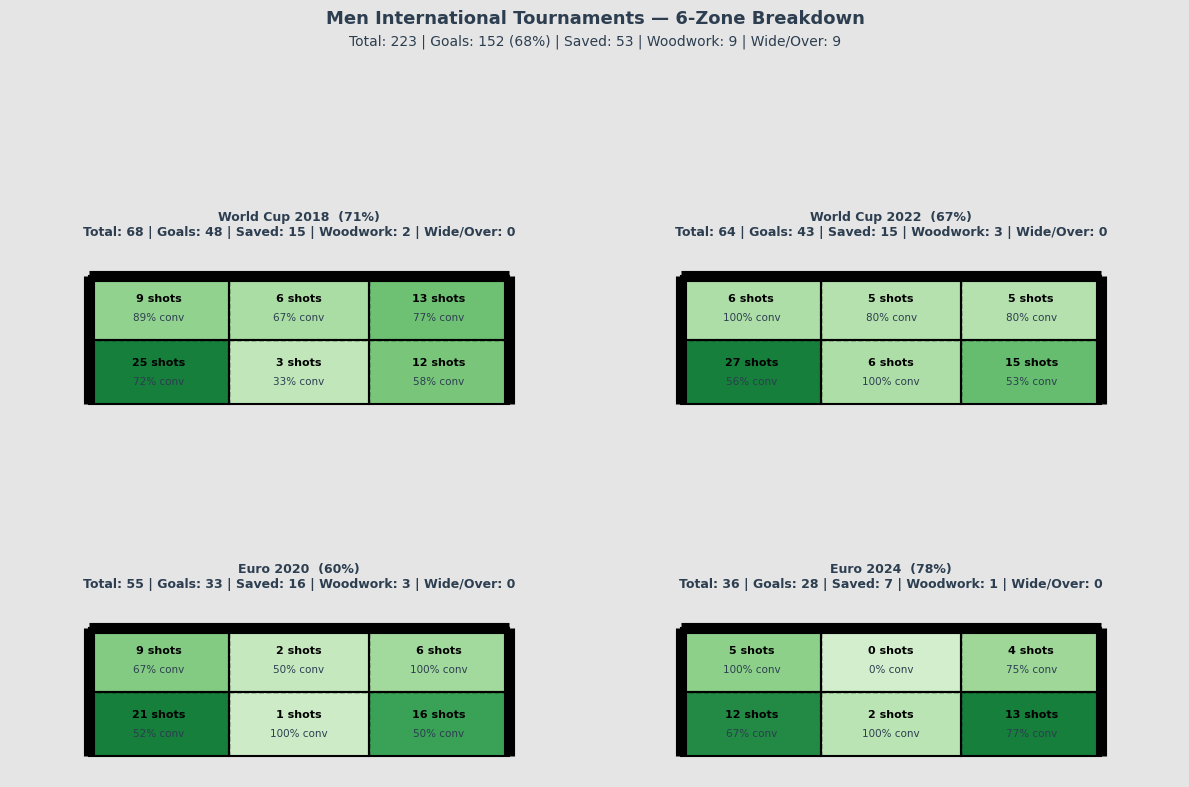

In [86]:
fig_men_zones   = plot_gender_zones(penalties_by_tournament, "Men",   men_labels,   men_display)

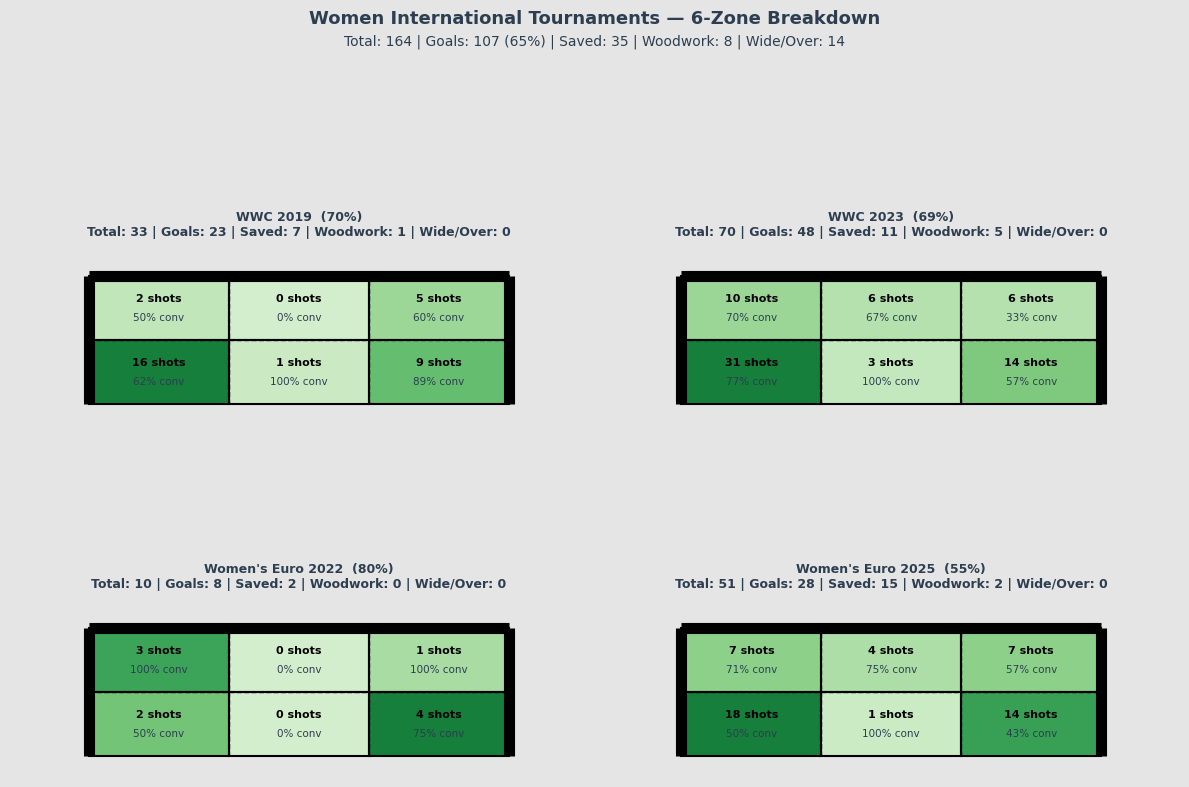

In [87]:
fig_women_zones = plot_gender_zones(penalties_by_tournament, "Women", women_labels, women_display)

In [88]:
euro_2020_matches = sb.matches(competition_id=55, season_id=43)

c:\Users\aquan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [89]:
euro_2020_matches

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3788758,2021-06-17,13:00:00.000,2,1,available,available,2026-05-09T08:43:52.942714,2026-05-09T08:47:21.438061,2,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,911,Ukraine,male,C,238,Ukraine,2358,North Macedonia,male,C,135,"Macedonia, Republic of",10,Group Stage,4365,Arena Naţională,187,Romania,1121,Fernando Andrés Rapallini,11,Argentina,Andrii Shevchenko,Igor Angelovski,2303,Andrii Shevchenko,NaN,1976-09-29,238,Ukraine,4172,Igor Angelovski,NaN,1976-06-02,135,"Macedonia, Republic of",1.1.0,2,2
1,3788773,2021-06-23,19:00:00.000,2,2,available,available,2026-05-09T08:40:28.668942,2026-05-09T08:41:55.755211,3,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,780,Portugal,male,F,183,Portugal,771,France,male,F,78,France,10,Group Stage,116551,Puskás Aréna,103,Hungary,180,Antonio Miguel Mateu Lahoz,214,Spain,Fernando Manuel Fernandes da Costa Santos,Didier Deschamps,607,Fernando Manuel Fernandes da Costa Santos,Fernando Santos,1954-10-10,183,Portugal,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
2,3788765,2021-06-20,16:00:00.000,3,1,available,available,2026-05-09T08:47:11.834605,2026-05-09T08:50:43.179455,3,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,773,Switzerland,male,A,221,Switzerland,909,Turkey,male,A,233,Turkey,10,Group Stage,4549,Bakı Olimpiya Stadionu,16,Azerbaijan,943,Slavko Vinčić,208,Slovenia,Vladimir Petković,Şenol Güneş,492,Vladimir Petković,NaN,1963-08-15,28,Bosnia and Herzegovina,701,Şenol Güneş,NaN,1952-06-01,233,Turkey,1.1.0,2,2
3,3788761,2021-06-18,13:00:00.000,1,0,available,available,2026-05-09T08:45:00.221474,2026-05-09T08:47:40.751022,2,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,790,Sweden,male,E,220,Sweden,908,Slovakia,male,E,207,Slovakia,10,Group Stage,4726,Saint-Petersburg Stadium ( Gazprom Arena ),188,Russia,225,Daniel Siebert,85,Germany,Jan Olof Andersson,Štefan Tarkovič,549,Jan Olof Andersson,NaN,1962-09-29,220,Sweden,5363,Štefan Tarkovič,NaN,1973-02-18,207,Slovakia,1.1.0,2,2
4,3788760,2021-06-18,16:00:00.000,1,1,available,available,2026-05-09T08:46:02.678251,2026-05-09T08:46:32.249784,2,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,785,Croatia,male,D,56,Croatia,912,Czech Republic,male,D,60,Czech Republic,10,Group Stage,52986,Hampden Park,201,Scotland,2728,Carlos del Cerro Grande,214,Spain,Zlatko Dalić,Jaroslav Šilhavý,307,Zlatko Dalić,NaN,1966-10-26,56,Croatia,183,Jaroslav Šilhavý,NaN,1961-11-03,60,Czech Republic,1.1.0,2,2
5,3795108,2021-07-02,16:00:00.000,1,1,available,available,2026-05-06T23:29:25.017271,2026-05-06T23:31:40.161883,5,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,773,Switzerland,male,A,221,Switzerland,772,Spain,male,E,214,Spain,11,Quarter-finals,4726,Saint-Petersburg Stadium ( Gazprom Arena ),188,Russia,1,Michael Oliver,68,England,Vladimir Petković,Luis Enrique Martínez García,492,Vladimir Petković,NaN,1963-08-15,28,Bosnia and Herzegovina,793,Luis Enrique Martínez García,Luis Enrique,1970-05-08,214,Spain,1.1.0,2,2
6,3794687,2021-06-27,19:00:00.000,1,0,available,available,2026-05-06T23:32:26.915562,2026-05-06T23:36:27.356611,4,55,Europe,UEFA Euro,Europe - UEFA Euro,43,2020,782,Belgium,male,NaN,22,

In [93]:
france_germany_events = sb.events(match_id = 3788751)

c:\Users\aquan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [94]:
france_germany_events.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_type,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_success_in_play,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04c8dd61-216b-4e4a-9d9b-b97a3043d6f6,1,NaN,NaN,NaN,3788751,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,France,771,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",France,771,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,602daf2d-9d5c-4f74-8681-27bd77fd18eb,2,NaN,NaN,NaN,3788751,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,France,771,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 3421, 'lineup': [{'player': {'id...",Germany,770,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,614df6f8-792f-42b2-b063-cfc4c4ae6802,3,NaN,NaN,NaN,3788751,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,France,771,[a85a27fd-5036-4842-8d40-4ba7b4ab1508],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,France,771,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a85a27fd-5036-4842-8d40-4ba7b4ab1508,4,NaN,NaN,NaN,3788751,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,France,771,[614df6f8-792f-42b2-b063-cfc4c4ae6802],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany,770,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f364db3e-f6f5-4733-95a4-f6063a3c7f3b,1969,NaN,NaN,NaN,3788751,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,73,France,771,[17d9fb87-8b55-4012-9533-f57216806b09],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Germany,770,00:00:00.000,Half Start,NaN


In [95]:
print(france_germany_events['type'].unique())

<StringArray>
[      'Starting XI',        'Half Start',              'Pass',
     'Ball Receipt*',             'Carry',          'Pressure',
      'Interception',    'Foul Committed',          'Foul Won',
              'Duel',              'Shot',       'Goal Keeper',
     'Ball Recovery',         'Clearance',           'Dribble',
      'Dispossessed',        'Miscontrol',             'Block',
     'Dribbled Past',      'Own Goal For',  'Own Goal Against',
            'Shield',          'Half End',   'Injury Stoppage',
      'Substitution', 'Referee Ball-Drop',    'Tactical Shift']
Length: 27, dtype: str


In [96]:
france_germany_og_for = sb.events(match_id = 3788751, split=True, flatten_attrs=True)['own_goal_fors']

c:\Users\aquan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [97]:
france_germany_og_for

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,location,duration,related_events,match_id,possession_team_id,team_id
0,37e46a9f-80c4-4a81-b87b-0f0917f7b16a,915,1,00:19:42.437,19,42,Own Goal For,35,France,From Throw In,France,"[113.4, 35.9]",0.0,[6d9b6176-6eb0-4b12-835b-6c40ec665398],3788751,771,771


In [98]:
france_germany_og_against = sb.events(match_id = 3788751, split=True, flatten_attrs=True)['own_goal_againsts']

c:\Users\aquan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [99]:
france_germany_og_against

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,related_events,match_id,possession_team_id,team_id,player_id
0,6d9b6176-6eb0-4b12-835b-6c40ec665398,916,1,00:19:42.437,19,42,Own Goal Against,35,France,From Throw In,Germany,Mats Hummels,Center Back,"[6.7, 44.2]",0.0,[37e46a9f-80c4-4a81-b87b-0f0917f7b16a],3788751,771,770,5572


In [90]:
france_germany_shots = sb.events(match_id = 3788751, split=True, flatten_attrs=True)['shots']

c:\Users\aquan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [91]:
france_germany_shots.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,team,player,position,location,duration,under_pressure,related_events,match_id,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_outcome,shot_technique,shot_aerial_won,shot_type,shot_body_part,shot_freeze_frame,possession_team_id,team_id,player_id,shot_first_time,out
0,046a2f70-66db-48d2-86d2-dc3c6fe24784,154,1,00:03:05.737,3,5,Shot,4,Germany,From Free Kick,Germany,Mats Hummels,Center Back,"[111.2, 37.0]",0.692259,True,"[7b9fbd7f-d796-4dcb-83e4-6eaedd01ce77, b0687fc...",3788751,0.067319,"[120.0, 38.5, 5.6]",8df824b0-74fd-4e7b-88d8-ca2f7fa7b1c3,Off T,Normal,True,Open Play,Head,"[{'location': [112.2, 36.5], 'player': {'id': ...",770,770,5572,NaN,NaN
1,fe730b9f-4d0e-4296-ba95-e618ee11e030,728,1,00:15:28.309,15,28,Shot,28,France,From Corner,France,Paul Pogba,Right Center Midfield,"[115.0, 39.9]",0.324732,True,"[160ca22f-99ae-4e54-a208-a2500b8ae514, 457cbd5...",3788751,0.210098,"[120.0, 40.6, 3.7]",21d2565c-8f25-4aa6-9754-89076ec1f20a,Off T,Normal,True,Open Play,Head,"[{'location': [115.5, 36.4], 'player': {'id': ...",771,771,20004,NaN,NaN
2,4d728636-9eda-478a-8f10-ee9a6044ef07,796,1,00:16:37.539,16,37,Shot,30,France,Regular Play,France,Kylian Mbappé Lottin,Left Wing,"[105.7, 26.3]",0.607676,NaN,[a3bfcf91-5e2d-4db0-bfe0-074af4e2ea55],3788751,0.046696,"[117.6, 38.1, 1.2]",5977d1b1-3051-4a8a-85b1-92fcc7020c05,Saved,Normal,NaN,Open Play,Right Foot,"[{'location': [98.8, 42.2], 'player': {'id': 2...",771,771,3009,NaN,NaN
3,9a186aed-c21d-4222-b527-dafbe14a658a,1003,1,00:21:52.366,21,52,Shot,38,Germany,Regular Play,Germany,Thomas Müller,Left Attacking Midfield,"[114.5, 32.9]",0.592925,NaN,[bc160298-a59b-4159-a715-933bac24bec2],3788751,0.155428,"[120.0, 62.5, 0.9]",7fee9d4f-6826-4301-8322-7d2ed1c83d61,Off T,Normal,NaN,Open Play,Head,"[{'location': [114.3, 12.3], 'player': {'id': ...",770,770,5562,NaN,NaN
4,1bc85708-054e-4ac2-89d0-216c52c1630d,1038,1,00:24:26.968,24,26,Shot,41,Germany,From Free Kick,Germany,Toni Kroos,Left Defensive Midfield,"[94.8, 32.4]",0.419922,NaN,"[39e6403e-ed76-4fa2-8bb3-a8eac1e94334, 4328011...",3788751,0.059551,"[105.0, 36.3]",NaN,Blocked,Normal,NaN,Free Kick,Right Foot,"[{'location': [96.8, 38.0], 'player': {'id': 3...",770,770,5574,NaN,NaN


In [92]:
print(france_germany_shots['shot_outcome'].unique())

<StringArray>
['Off T', 'Saved', 'Blocked', 'Post']
Length: 4, dtype: str
